## Setup

In [1]:
import numpy as np
import pandas as pd
import pickle
import random

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score, roc_auc_score
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import OrdinalEncoder

# For experiment analysis (keeping parallel to andrew's baseline)
import itertools
import statistics
import matplotlib.pyplot as plt
import seaborn as sns

import exp as exptb

# For trying class balancing
from imblearn.over_sampling import SMOTE

In [2]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# "label" for comparability and comparability with andrew's encoded pipeline.
ENCODING_MODE = "label"   # onehot for future upgrade.
BATCH_SIZE = 512
EPOCHS = 40
LR = 1e-3
WEIGHT_DECAY = 1e-4
PATIENCE = 6


## Dataset Analysis & preprocessing

In [40]:
# Load and begin prepping strip search data
df = pd.read_csv('./datasets/torontostripsearch.csv', delimiter=',');df.head()

,Arrest_Year,Arrest_Month,EventID,ArrestID,PersonID,Perceived_Race,Sex,Age_group__at_arrest_,Youth_at_arrest__under_18_years,ArrestLocDiv,...,Actions_at_arrest___Resisted__d,Actions_at_arrest___Mental_inst,Actions_at_arrest___Assaulted_o,Actions_at_arrest___Cooperative,SearchReason_CauseInjury,SearchReason_AssistEscape,SearchReason_PossessWeapons,SearchReason_PossessEvidence,ItemsFound,ObjectId
0,2020,July-Sept,1005907,6017884.0,326622,White,M,Aged 35 to 44 years,Not a youth,54,...,0,0,0,1,NaN,NaN,NaN,NaN,NaN,1
1,2020,July-Sept,1014562,6056669.0,326622,White,M,Aged 35 to 44 years,Not a youth,54,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,2
2,2020,Oct-Dec,1029922,6057065.0,326622,Unknown or Legacy,M,Aged 35 to 44 years,Not a youth,54,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,3
3,2021,Jan-Mar,1052190,6029059.0,327535,Black,M,Aged 25 to 34 years,Not a youth,XX,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,4
4,2021,Jan-Mar,1015512,6040372.0,327535,South Asian,M,Aged 25 to 34 years,Not a youth,XX,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,5


In [4]:
for col in df.columns:
    print(f"{col}: {df[col].nunique()}") #list unique valuyes for each column to get a sense of the data.
    print(df[col].unique())


Arrest_Year: 2
[2020 2021]
Arrest_Month: 4
['July-Sept' 'Oct-Dec' 'Jan-Mar' 'Apr-June']
EventID: 60003
[1005907 1014562 1029922 ... 1021067 1008998 1033395]
ArrestID: 64805
[6017884. 6056669. 6057065. ... 6064396. 6008662. 6032145.]
PersonID: 37347
[326622 327535 330778 ... 324057 331870 310583]
Perceived_Race: 8
['White' 'Unknown or Legacy' 'Black' 'South Asian' 'Indigenous'
 'Middle-Eastern' 'Latino' 'East/Southeast Asian' nan]
Sex: 3
['M' 'F' 'U']
Age_group__at_arrest_: 9
['Aged 35 to 44 years' 'Aged 25 to 34 years' 'Aged 45 to 54 years'
 'Aged 55 to 64 years' 'Aged 18 to 24 years' 'Aged 65 and older'
 'Aged 65 years and older' nan 'Aged 17 years and younger'
 'Aged 17 years and under']
Youth_at_arrest__under_18_years: 3
['Not a youth' 'Youth (aged 17 and younger)'
 'Youth (aged 17 years and under)']
ArrestLocDiv: 18
['54' 'XX' '42' '52' '14' '51' '53' '31' '11' '12' '13' '41' '22' '55'
 '43' '23' '33' '32']
StripSearch: 2
[0 1]
Booked: 2
[1 0]
Occurrence_Category: 31
['Assault & Ot

In [5]:

df['IsYouth'] = np.where(df['Youth_at_arrest__under_18_years'] == "Not a youth", 0, 1)
df = df.rename(columns={"Arrest_Month" : "Arrest_Quarter"})
df.drop(columns=df.columns.intersection(['SearchReason_CauseInjury', 'SearchReason_AssistEscape', 'SearchReason_PossessWeapons', 'Arrest_Year',
                                         'SearchReason_PossessEvidence', 'Youth_at_arrest__under_18_years', "_defensive_or_escape_risk",
                                         'ObjectId', 'EventID', 'ArrestID', 'PersonID', 'Booked', 'ItemsFound']), axis=1, inplace=True)

df.replace({'Perceived_Race': {np.nan: 'Unknown or Legacy'}}, inplace=True)

df = df.drop(df[df['Sex'] == 'U'].index)

df.dropna(how="any", inplace=True)
categorical_features = ['Perceived_Race', 'Sex', 'Occurrence_Category', 'ArrestLocDiv']
ordinal_features = ['Age_group__at_arrest_', 'Arrest_Quarter']
binary_features = ['IsYouth','Actions_at_arrest___Concealed_i', 'Actions_at_arrest___Combative__',
                  'Actions_at_arrest___Resisted__d', 'Actions_at_arrest___Mental_inst',
                  'Actions_at_arrest___Assaulted_o', 'Actions_at_arrest___Cooperative']


X = df.drop('StripSearch', axis=1)
X = X.drop('IsYouth', axis=1) # keep IsYouth and change how it affects the model in future work
y = df['StripSearch']

# Map the age groups to the specified values
custom_mapping = {
    'Aged 17 years and under': 0,
    'Aged 17 years and younger': 0,
    'Aged 18 to 24 years': 1,
    'Aged 25 to 34 years': 2,
    'Aged 35 to 44 years': 3,
    'Aged 45 to 54 years': 4,
    'Aged 55 to 64 years': 5,
    'Aged 65 and older': 6,
    'Aged 65 years and older': 6
}

quarter_mapping = {
"Jan-Mar" : 0,
"Apr-June" : 1,
"July-Sept" : 3,
"Oct-Dec" : 4
}

X['Age_group__at_arrest_'] = X['Age_group__at_arrest_'].map(custom_mapping)
X['Arrest_Quarter'] = X['Arrest_Quarter'].map(quarter_mapping)

# Store the reverse mappings for later use in analysis and visualization
rev_custom_mapping = {
    0 : 'Aged 17 years and younger',
    1 : 'Aged 18 to 24 years'      ,
    2 : 'Aged 25 to 34 years'      ,
    3 : 'Aged 35 to 44 years'      ,
    4 : 'Aged 45 to 54 years'      ,
    5 : 'Aged 55 to 64 years'      ,
    6 : 'Aged 65 and older'        
}

rev_quarter_mapping = {
    0 : "Jan-Mar"   ,
    1 : "Apr-June"  ,
    3 : "July-Sept" ,
    4 : "Oct-Dec"   
}

custom_encoders = {
    'Age_group__at_arrest_': rev_custom_mapping,
    'Arrest_Quarter': rev_quarter_mapping
}

In [6]:
X.head()

,Arrest_Quarter,Perceived_Race,Sex,Age_group__at_arrest_,ArrestLocDiv,Occurrence_Category,Actions_at_arrest___Concealed_i,Actions_at_arrest___Combative__,Actions_at_arrest___Resisted__d,Actions_at_arrest___Mental_inst,Actions_at_arrest___Assaulted_o,Actions_at_arrest___Cooperative
0,3,White,M,3,54,Assault & Other crimes against persons,0,0,0,0,0,1
1,3,White,M,3,54,Assault & Other crimes against persons,0,0,0,0,0,0
2,4,Unknown or Legacy,M,3,54,Assault & Other crimes against persons,0,0,0,0,0,0
3,0,Black,M,2,XX,Harassment/Threatening,0,0,0,0,0,0
4,0,South Asian,M,2,XX,FTA/FTC/Compliance Check/Parollee,0,0,0,0,0,0


In [7]:
# train/test split (same as Andrew)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Build analysis copies with label encoding so slicing/explanation-table code still works
X_train_analysis = X_train.copy()
X_test_analysis = X_test.copy()

#Analysing which encoders we require for our Dataset and NN baseline
# 1. We have 4 categorical features: Perceived_Race, Sex, Occurrence_Category, ArrestLocDiv
# 2. We have 2 ordinal features: Age_group__at_arrest_, Arrest
# 3. We have 7 binary features: IsYouth, Actions_at_arrest___Concealed_i, Actions_at_arrest___Combative__, Actions_at_arrest___Resisted__d, Actions_at_arrest___Mental_inst, Actions_at_arrest___Assaulted_o, Actions_at_arrest___Cooperative

# Output directories for NN baseline artifacts
import os
OUT_BASE_DIR = "baseline_nn_output"
ENCODER_DIR = os.path.join(OUT_BASE_DIR, "encoder_tables")
FP_DIR = os.path.join(OUT_BASE_DIR, "fp_analysis")
DICE_DIR = os.path.join(OUT_BASE_DIR, "dice_cf")
RECOURSE_TEMP_DIR = os.path.join(OUT_BASE_DIR, "recourse_temp")
RECOURSE_TABLE_DIR = os.path.join(OUT_BASE_DIR, "recourse_tables")
for _d in [ENCODER_DIR, FP_DIR, DICE_DIR, RECOURSE_TEMP_DIR, RECOURSE_TABLE_DIR]:
    os.makedirs(_d, exist_ok=True)
print("Output dirs ready under:", OUT_BASE_DIR)



Output dirs ready under: baseline_nn_output


## Encoder Analysis
 1) categorical features (label encoder), ordinal features (ordinal encoder), binary features (passthrough)
 2) categorical features (one-hot), ordinal features (ordinal encoder), binary features (passthrough)
 3) categorical features (one-hot), ordinal features (ordinal encoder), binary features (one-hot )


In [8]:
# Base split copies (avoid accidental in-place mutation across cases)
X_train_base = X_train.copy(deep=True)
X_test_base = X_test.copy(deep=True)

# Labels once (shared across all cases)
y_train_np = y_train.to_numpy(dtype=np.float32)
y_test_np = y_test.to_numpy(dtype=np.float32)


def build_ohe():
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)


def build_ord():
    # Safer than default: does not crash on unseen test categories
    return OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)

# Keep only columns that are actually present in model frame (e.g., IsYouth may be dropped upstream)
cat_cols = [c for c in categorical_features if c in X_train_base.columns]
ord_cols = [c for c in ordinal_features if c in X_train_base.columns]
bin_cols = [c for c in binary_features if c in X_train_base.columns]

missing_cat = sorted(set(categorical_features) - set(cat_cols))
missing_ord = sorted(set(ordinal_features) - set(ord_cols))
missing_bin = sorted(set(binary_features) - set(bin_cols))

if missing_cat or missing_ord or missing_bin:
    print(" Skipped missing columns ->")
    print("  categorical:", missing_cat)
    print("  ordinal:", missing_ord)
    print("  binary:", missing_bin)

def run_case(case_name, preprocessor, Xtr, Xte, y_train_np, y_test_np, smote=False):
    
        
    Xtr_enc = preprocessor.fit_transform(Xtr)
    Xte_enc = preprocessor.transform(Xte)

    if smote:
        smote_sampler = SMOTE(random_state=42)
        Xtr_enc, y_train_np = smote_sampler.fit_resample(X=Xtr_enc, y=y_train_np)
        y_train_np = y_train_np.to_numpy(dtype=np.float32)

    scaler_local = StandardScaler()
    Xtr_np = scaler_local.fit_transform(Xtr_enc).astype(np.float32)
    Xte_np = scaler_local.transform(Xte_enc).astype(np.float32)

    print(case_name)
    print("  X_train:", Xtr_np.shape)
    print("  X_test :", Xte_np.shape)
    print("  Positive class ratio (train):", y_train_np.mean())
    
    
        

    return {
        "name": case_name,
        "preprocessor": preprocessor,
        "scaler": scaler_local,
        "X_train_np": Xtr_np,
        "X_test_np": Xte_np,
        "y_train_np": y_train_np,
        "y_test_np": y_test_np,
    }


# Case 1: encoded categorical + ordinal-encoded ordinal + binary passthrough
preprocessor_c1 = ColumnTransformer(
    transformers=[
        ("cat_ordenc", build_ord(), cat_cols),
        ("ord_ordenc", build_ord(), ord_cols),
        ("bin_pass", "passthrough", bin_cols),
    ],
    remainder="drop",
)

# Case 2: one-hot categorical + ordinal-encoded ordinal + binary passthrough
preprocessor_c2 = ColumnTransformer(
    transformers=[
        ("cat_ohe", build_ohe(), cat_cols),
        ("ord_ordenc", build_ord(), ord_cols),
        ("bin_pass", "passthrough", bin_cols),
    ],
    remainder="drop",
)

# Case 3: one-hot categorical + ordinal-encoded ordinal + one-hot binary
preprocessor_c3 = ColumnTransformer(
    transformers=[
        ("cat_ohe", build_ohe(), cat_cols),
        ("ord_ordenc", build_ord(), ord_cols),
        ("bin_ohe", build_ohe(), bin_cols),
    ],
    remainder="drop",
)

case1 = run_case(
    "Case 1 cat-encoded + ord-encoded + bin-passthrough",
    preprocessor_c1,
    X_train_base,
    X_test_base,
    y_train_np, 
    y_test_np
)
case2 = run_case(
    "Case 2 one-hot + ord-encoded + bin-passthrough",
    preprocessor_c2,
    X_train_base,
    X_test_base,
    y_train_np, 
    y_test_np
)
case3 = run_case(
    "Case 3 one-hot + ord-encoded + one-hot",
    preprocessor_c3,
    X_train_base,
    X_test_base,
    y_train_np, 
    y_test_np
)

case4 = run_case(
    "Case 4 one-hot + ord-encoded + one-hot + SMOTE class rebalance",
    preprocessor_c3,
    X_train_base,
    X_test_base,
    y_train, 
    y_test_np,
    smote=True
)



 Skipped missing columns ->
  categorical: []
  ordinal: []
  binary: ['IsYouth']
Case 1 cat-encoded + ord-encoded + bin-passthrough
  X_train: (52062, 12)
  X_test : (13016, 12)
  Positive class ratio (train): 0.119857095
Case 2 one-hot + ord-encoded + bin-passthrough
  X_train: (52062, 67)
  X_test : (13016, 67)
  Positive class ratio (train): 0.119857095
Case 3 one-hot + ord-encoded + one-hot
  X_train: (52062, 73)
  X_test : (13016, 73)
  Positive class ratio (train): 0.119857095
Case 4 one-hot + ord-encoded + one-hot + SMOTE class rebalance
  X_train: (91644, 73)
  X_test : (13016, 73)
  Positive class ratio (train): 0.5


In [9]:
# Train/val split for early stopping for each case (same as Andrew)
def train_val_split(X, y, val_size=0.2):
    return train_test_split(X, y, test_size=val_size, random_state=42, stratify=y)

train_val_splits = {}
for case in [case1, case2, case4]:
    X_tr, X_val, y_tr, y_val = train_val_split(case["X_train_np"], case["y_train_np"])
    train_val_splits[case["name"]] = {
        "X_tr": X_tr,
        "y_tr": y_tr,
        "X_val": X_val,
        "y_val": y_val,}
    
    train_ds = TensorDataset(torch.from_numpy(X_tr), torch.from_numpy(y_tr))
    val_ds = TensorDataset(torch.from_numpy(X_val), torch.from_numpy(y_val))
    case["train_loader"] = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
    case["val_loader"] = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
    

In [10]:
# Testing what happens when we applying smote to deal with the class imbalance
X_tr, X_val, y_tr, y_val = train_val_split(case3["X_train_np"], case3["y_train_np"])
print("Before applying smote to class imbalance")
print(f"num samples: {y_tr.shape[0]}, num class = 1 samples: {y_tr.sum()}, num class = 0 samples: {y_tr.shape[0] - y_tr.sum()}, ratio positive: {y_tr.sum()/y_tr.shape[0]:.2f}")

smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_tr, y_tr)

print("After applying smote to class imbalance")
print(f"num samples: {y_resampled.shape[0]}, num class = 1 samples: {y_resampled.sum()}, num class = 0 samples: {y_resampled.shape[0] - y_resampled.sum()}, ratio positive: {y_resampled.sum()/y_resampled.shape[0]:.2f}")
# included this as case 4 above

Before applying smote to class imbalance
num samples: 41649, num class = 1 samples: 4992.0, num class = 0 samples: 36657.0, ratio positive: 0.12
After applying smote to class imbalance
num samples: 73314, num class = 1 samples: 36657.0, num class = 0 samples: 36657.0, ratio positive: 0.50


### Neural Network

In [11]:
class MLPBaseline(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        return self.net(x).squeeze(1)   

def train_model(model, train_loader, val_loader, epochs=EPOCHS, lr=LR, weight_decay=WEIGHT_DECAY, patience=PATIENCE):
    criterion = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    best_val_loss = float('inf')
    patience_counter = 0
    best_state = None

    for epoch in range(epochs):
        model.train()
        train_losses = []
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()
            train_losses.append(loss.item())

        avg_train_loss = np.mean(train_losses)

        model.eval()
        val_losses = []
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
                outputs = model(X_batch)
                loss = criterion(outputs, y_batch)
                val_losses.append(loss.item())

        avg_val_loss = np.mean(val_losses)

        print(f"Epoch {epoch+1}/{epochs} - Train Loss: {avg_train_loss:.4f} - Val Loss: {avg_val_loss:.4f}")

        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print("Early stopping triggered.")
                break
            
    if best_state is not None:
        model.load_state_dict(best_state)

### Test Set Evaluation

In [12]:
def label_false_positives(X_test, y_test, y_pred):
    fps = np.zeros(y_pred.shape[0])
    y_truth = y_test.copy().reset_index(drop=True)
    test_copy = X_test.copy().reset_index(drop=True)
    for i in test_copy.itertuples():
        if y_pred[i[0]] == 1 and y_truth[i[0]] == 0:
            fps[i[0]] = 1
    test_copy["targetcol"] = np.round(fps, 2)
    return test_copy

def label_false_negatives(X_test, y_test, y_pred):
    fns = np.zeros(y_pred.shape[0])
    y_truth = y_test.copy().reset_index(drop=True)
    test_copy = X_test.copy().reset_index(drop=True)
    for i in test_copy.itertuples():
        if y_pred[i[0]] == 0 and y_truth[i[0]] == 1:
            fns[i[0]] = 1
    test_copy["targetcol"] = np.round(fns, 2)
    return test_copy


def make_loaders(X_train_np, y_train_np, batch_size=512, seed=42, val_size=0.1):
    X_tr, X_val, y_tr, y_val = train_test_split(
        X_train_np, y_train_np, test_size=val_size, random_state=seed, stratify=y_train_np
    )
    train_ds = TensorDataset(
        torch.tensor(X_tr, dtype=torch.float32),
        torch.tensor(y_tr, dtype=torch.float32),
    )
    val_ds = TensorDataset(
        torch.tensor(X_val, dtype=torch.float32),
        torch.tensor(y_val, dtype=torch.float32),
    )
    return (
        DataLoader(train_ds, batch_size=batch_size, shuffle=True),
        DataLoader(val_ds, batch_size=batch_size, shuffle=False),
    )


def evaluate_model(model, X_test_np, y_test_np):
    model.eval()
    with torch.no_grad():
        x = torch.tensor(X_test_np, dtype=torch.float32, device=DEVICE)
        logits = model(x)            
        logits = logits.reshape(-1)    # robust for [N] or [N,1]
        probs = torch.sigmoid(logits).cpu().numpy()

    y_pred = (probs >= 0.5).astype(int)
    y_true = np.asarray(y_test_np).astype(int).reshape(-1)

    return {
        "y_pred": y_pred,
        "y_prob": probs,
        "accuracy": accuracy_score(y_true, y_pred),
        "f1": f1_score(y_true, y_pred),
        "roc_auc": roc_auc_score(y_true, probs),
    }


In [13]:
results = {}
X_test_for_labels = X_test.copy().reset_index(drop=True)   # raw/readable frame
y_test_series = y_test.copy().reset_index(drop=True)       # for our FP/FN funcs

for case in [case1, case2, case3, case4]:
    print(f"\nTraining {case['name']}...")
    train_loader, val_loader = make_loaders(
        case["X_train_np"], case["y_train_np"], batch_size=BATCH_SIZE, seed=SEED
    )

    model = MLPBaseline(input_dim=case["X_train_np"].shape[1]).to(DEVICE)
    train_model(model, train_loader, val_loader)

    eval_out = evaluate_model(model, case["X_test_np"], case["y_test_np"])
    results[case["name"]] = {
        **eval_out,
        "model": model,
    }

    print(
        f"{case['name']} | Acc={eval_out['accuracy']:.4f} | "
        f"F1={eval_out['f1']:.4f} | ROC-AUC={eval_out['roc_auc']:.4f}"
    )

# metric table
metrics_df = pd.DataFrame([
    {"case": k, "accuracy": v["accuracy"], "f1": v["f1"], "roc_auc": v["roc_auc"]}
    for k, v in results.items()
]).sort_values("roc_auc", ascending=False)
display(metrics_df)

# FP/FN labeled tables by case
fp_tables = {}
fn_tables = {}
for case_name, out in results.items():
    fp_tables[case_name] = label_false_positives(X_test_for_labels, y_test_series, out["y_pred"])
    fn_tables[case_name] = label_false_negatives(X_test_for_labels, y_test_series, out["y_pred"])
    print(case_name, "| FP:", int(fp_tables[case_name]["targetcol"].sum()),
          "| FN:", int(fn_tables[case_name]["targetcol"].sum()))



Training Case 1 cat-encoded + ord-encoded + bin-passthrough...
Epoch 1/40 - Train Loss: 0.3911 - Val Loss: 0.3447
Epoch 2/40 - Train Loss: 0.3429 - Val Loss: 0.3404
Epoch 3/40 - Train Loss: 0.3387 - Val Loss: 0.3371
Epoch 4/40 - Train Loss: 0.3362 - Val Loss: 0.3349
Epoch 5/40 - Train Loss: 0.3332 - Val Loss: 0.3324
Epoch 6/40 - Train Loss: 0.3302 - Val Loss: 0.3314
Epoch 7/40 - Train Loss: 0.3289 - Val Loss: 0.3284
Epoch 8/40 - Train Loss: 0.3268 - Val Loss: 0.3261
Epoch 9/40 - Train Loss: 0.3251 - Val Loss: 0.3265
Epoch 10/40 - Train Loss: 0.3226 - Val Loss: 0.3238
Epoch 11/40 - Train Loss: 0.3218 - Val Loss: 0.3239
Epoch 12/40 - Train Loss: 0.3212 - Val Loss: 0.3229
Epoch 13/40 - Train Loss: 0.3203 - Val Loss: 0.3214
Epoch 14/40 - Train Loss: 0.3186 - Val Loss: 0.3227
Epoch 15/40 - Train Loss: 0.3179 - Val Loss: 0.3215
Epoch 16/40 - Train Loss: 0.3179 - Val Loss: 0.3201
Epoch 17/40 - Train Loss: 0.3160 - Val Loss: 0.3192
Epoch 18/40 - Train Loss: 0.3166 - Val Loss: 0.3189
Epoch 19/

,case,accuracy,f1,roc_auc
1,Case 2 one-hot + ord-encoded + bin-passthrough,0.899969,0.456140,0.896173
2,Case 3 one-hot + ord-encoded + one-hot,0.900200,0.458975,0.896153
3,Case 4 one-hot + ord-encoded + one-hot + SMOTE...,0.840350,0.521198,0.882426
0,Case 1 cat-encoded + ord-encoded + bin-passthr...,0.883221,0.115250,0.811941


Case 1 cat-encoded + ord-encoded + bin-passthrough | FP: 59 | FN: 1461
Case 2 one-hot + ord-encoded + bin-passthrough | FP: 288 | FN: 1014
Case 3 one-hot + ord-encoded + one-hot | FP: 290 | FN: 1009
Case 4 one-hot + ord-encoded + one-hot + SMOTE class rebalance | FP: 1649 | FN: 429


## Case 5: Multi-adversarial debiasing (on top of the SMOTE baseline)

- in-processing debiasing variant for the NN baseline. 
- Adapting Andrew's Case 4 "encoding + SMOTE setup". 
- Train the predictor against multiple adversaries for `Perceived_Race`, `Sex`, and the `Race x Sex` intersection. `age` for later experiments.

### CAse5 : TRaining

In [14]:
from multi_adversarial_debiasing import (
    MultiAdversarialMLP,
    evaluate_multi_adversarial_model,
    make_adversarial_loaders,
    prepare_smote_case_with_sensitive_labels,
    train_multi_adversarial_model,
)

case5_name = "Case 5 one-hot + ord-encoded + one-hot + SMOTE + multi-adversarial debiasing"
case5_protected_cols = ["Perceived_Race", "Sex"]

case5 = prepare_smote_case_with_sensitive_labels(
    case_name=case5_name,
    preprocessor=preprocessor_c3,
    x_train_raw=X_train_base,
    x_test_raw=X_test_base,
    y_train=y_train,
    y_test=y_test,
    protected_cols=case5_protected_cols,
    random_state=SEED,
)

# Add an intersection adversary so the representation is discouraged from encoding
# both single-attribute and intersectional sensitive signals.
race_targets = case5["protected_targets"]["Perceived_Race"]
sex_targets = case5["protected_targets"]["Sex"]
sex_cardinality = len(case5["protected_classes"]["Sex"])
case5["protected_targets"]["Race_Sex_intersection"] = race_targets * sex_cardinality + sex_targets
case5["protected_classes"]["Race_Sex_intersection"] = [
    f"{race}|{sex}"
    for race in case5["protected_classes"]["Perceived_Race"]
    for sex in case5["protected_classes"]["Sex"]
]

train_loader_case5, val_loader_case5, case5_protected_order = make_adversarial_loaders(
    case5["X_train_np"],
    case5["y_train_np"],
    case5["protected_targets"],
    batch_size=BATCH_SIZE,
    seed=SEED,
    val_size=0.1,
)

case5_model = MultiAdversarialMLP(
    input_dim=case5["X_train_np"].shape[1],
    protected_output_dims={
        name: len(case5["protected_classes"][name])
        for name in case5_protected_order
    },
).to(DEVICE)

case5_history = train_multi_adversarial_model(
    case5_model,
    train_loader_case5,
    val_loader_case5,
    case5_protected_order,
    device=DEVICE,
    epochs=EPOCHS,
    lr=LR,
    weight_decay=WEIGHT_DECAY,
    patience=PATIENCE,
    adv_lambda=1.0,
    adv_weight=0.5,
)

case5_eval = evaluate_multi_adversarial_model(
    case5_model,
    case5["X_test_np"],
    case5["y_test_np"],
    DEVICE,
)
results[case5_name] = {
    **case5_eval,
    "model": case5_model,
    "history": case5_history,
}

fp_tables[case5_name] = label_false_positives(X_test_for_labels, y_test_series, case5_eval["y_pred"])
fn_tables[case5_name] = label_false_negatives(X_test_for_labels, y_test_series, case5_eval["y_pred"])

print(
    f"{case5_name} | Acc={case5_eval['accuracy']:.4f} | "
    f"F1={case5_eval['f1']:.4f} | ROC-AUC={case5_eval['roc_auc']:.4f}"
)
print(
    case5_name,
    "| FP:", int(fp_tables[case5_name]["targetcol"].sum()),
    "| FN:", int(fn_tables[case5_name]["targetcol"].sum()),
)

metrics_df = pd.DataFrame([
    {"case": k, "accuracy": v["accuracy"], "f1": v["f1"], "roc_auc": v["roc_auc"]}
    for k, v in results.items()
]).sort_values("roc_auc", ascending=False)
display(metrics_df)



Epoch 1/40 | task_train=0.4435 | adv_train=4.3077 | task_val=0.3864 | adv_val=4.0311 | lambda=0.025
Epoch 2/40 | task_train=0.3832 | adv_train=4.0884 | task_val=0.3703 | adv_val=3.9299 | lambda=0.050
Epoch 3/40 | task_train=0.3676 | adv_train=3.9336 | task_val=0.3570 | adv_val=3.9443 | lambda=0.075
Epoch 4/40 | task_train=0.3558 | adv_train=3.9470 | task_val=0.3479 | adv_val=3.7427 | lambda=0.100
Epoch 5/40 | task_train=0.3458 | adv_train=3.9276 | task_val=0.3392 | adv_val=3.8377 | lambda=0.125
Epoch 6/40 | task_train=0.3392 | adv_train=3.9321 | task_val=0.3306 | adv_val=3.8228 | lambda=0.150
Epoch 7/40 | task_train=0.3327 | adv_train=3.9207 | task_val=0.3241 | adv_val=3.8764 | lambda=0.175
Epoch 8/40 | task_train=0.3273 | adv_train=3.9217 | task_val=0.3216 | adv_val=3.8626 | lambda=0.200
Epoch 9/40 | task_train=0.3232 | adv_train=3.9184 | task_val=0.3227 | adv_val=3.9347 | lambda=0.225
Epoch 10/40 | task_train=0.3214 | adv_train=3.9296 | task_val=0.3148 | adv_val=3.8905 | lambda=0.250

,case,accuracy,f1,roc_auc
1,Case 2 one-hot + ord-encoded + bin-passthrough,0.899969,0.456140,0.896173
2,Case 3 one-hot + ord-encoded + one-hot,0.900200,0.458975,0.896153
3,Case 4 one-hot + ord-encoded + one-hot + SMOTE...,0.840350,0.521198,0.882426
4,Case 5 one-hot + ord-encoded + one-hot + SMOTE...,0.840274,0.520857,0.881296
0,Case 1 cat-encoded + ord-encoded + bin-passthr...,0.883221,0.115250,0.811941


### Disparity Case5 (Race,SEx, Race X Sex)

In [15]:
protected_cols = ["Perceived_Race", "Sex", "Race_Sex_intersection"]

y_true = y_test.reset_index(drop=True).astype(int)
X_grp = X_test.reset_index(drop=True).copy()
X_grp["Race_Sex_intersection"] = (
    X_grp["Perceived_Race"].astype(str) + " | " + X_grp["Sex"].astype(str)
)

def safe_div(a, b):
    return a / b if b != 0 else np.nan

def group_error_table(X_raw, y_true, y_pred, group_col):
    df = pd.DataFrame({
        "group": X_raw[group_col].reset_index(drop=True),
        "y_true": y_true.reset_index(drop=True).astype(int),
        "y_pred": pd.Series(y_pred).reset_index(drop=True).astype(int)
    })

    rows = []
    for g, part in df.groupby("group"):
        yt = part["y_true"].to_numpy()
        yp = part["y_pred"].to_numpy()

        tp = int(((yt == 1) & (yp == 1)).sum())
        tn = int(((yt == 0) & (yp == 0)).sum())
        fp = int(((yt == 0) & (yp == 1)).sum())
        fn = int(((yt == 1) & (yp == 0)).sum())
        n = len(part)

        tpr = safe_div(tp, tp + fn)
        fpr = safe_div(fp, fp + tn)
        fnr = safe_div(fn, tp + fn)
        sel = safe_div(tp + fp, n)

        rows.append({
            "group": g, "count": n, "TP": tp, "TN": tn, "FP": fp, "FN": fn,
            "TPR": tpr, "FPR": fpr, "FNR": fnr, "SelectionRate": sel
        })

    out = pd.DataFrame(rows).sort_values("count", ascending=False).reset_index(drop=True)
    return out

def disparity_summary(group_df, metrics=("TPR", "FPR", "FNR", "SelectionRate")):
    d = {}
    for m in metrics:
        vals = group_df[m].dropna()
        d[f"{m}_gap"] = (vals.max() - vals.min()) if len(vals) else np.nan
    # Equalized Odds-style scalar (smaller is better)
    d["EO_gap_max"] = np.nanmax([d["TPR_gap"], d["FPR_gap"]])
    return d

group_tables = {}
summary_rows = []

for case_name, out in results.items():
    y_pred = out["y_pred"]

    for col in protected_cols:
        gtab = group_error_table(X_grp, y_true, y_pred, col)
        group_tables[(case_name, col)] = gtab

        gaps = disparity_summary(gtab)
        summary_rows.append({
            "case": case_name,
            "attribute": col,
            "accuracy": out["accuracy"],
            "f1": out["f1"],
            "roc_auc": out["roc_auc"],
            **gaps
        })

# Detailed per-group tables
for (case_name, col), tbl in group_tables.items():
    print(f"\n=== {case_name} | {col} ===")
    display(tbl)

# Compact comparison table for decision
summary_df = pd.DataFrame(summary_rows).sort_values(
    by=["attribute", "EO_gap_max", "FNR_gap", "FPR_gap", "f1"],
    ascending=[True, True, True, True, False]
).reset_index(drop=True)

print("\n=== Disparity Summary (lower gaps better) ===")
display(summary_df)

#Save this summary table and all the group tables for later analysis and visualization in the next notebook.
summary_df.to_csv(os.path.join(ENCODER_DIR, "disparity_summary.csv"), index=False)

for (case_name, col), tbl in group_tables.items():
    tbl.to_csv(os.path.join(ENCODER_DIR, f"group_table_{case_name}_{col}.csv"), index=False)



=== Case 1 cat-encoded + ord-encoded + bin-passthrough | Perceived_Race ===


,group,count,TP,TN,FP,FN,TPR,FPR,FNR,SelectionRate
0,White,5501,42,4754,24,681,0.058091,0.005023,0.941909,0.011998
1,Black,3464,41,2951,24,448,0.083845,0.008067,0.916155,0.018764
2,Unknown or Legacy,1135,5,1026,1,103,0.046296,0.000974,0.953704,0.005286
3,East/Southeast Asian,839,5,772,3,59,0.078125,0.003871,0.921875,0.009535
4,South Asian,712,4,663,0,45,0.081633,0.000000,0.918367,0.005618
5,Middle-Eastern,623,0,572,4,47,0.000000,0.006944,1.000000,0.006421
6,Indigenous,392,1,335,1,55,0.017857,0.002976,0.982143,0.005102
7,Latino,350,1,324,2,23,0.041667,0.006135,0.958333,0.008571



=== Case 1 cat-encoded + ord-encoded + bin-passthrough | Sex ===


,group,count,TP,TN,FP,FN,TPR,FPR,FNR,SelectionRate
0,M,10477,80,9147,41,1209,0.062064,0.004462,0.937936,0.011549
1,F,2539,19,2250,18,252,0.070111,0.007937,0.929889,0.014573



=== Case 1 cat-encoded + ord-encoded + bin-passthrough | Race_Sex_intersection ===


...

,group,count,TP,TN,FP,FN,TPR,FPR,FNR,SelectionRate
0,M,10477,944,7833,1355,345,0.732351,0.147475,0.267649,0.219433
1,F,2539,186,1974,294,85,0.686347,0.129630,0.313653,0.189051



=== Case 5 one-hot + ord-encoded + one-hot + SMOTE + multi-adversarial debiasing | Race_Sex_intersection ===


,group,count,TP,TN,FP,FN,TPR,FPR,FNR,SelectionRate
0,White | M,4273,427,3171,549,126,0.772152,0.147581,0.227848,0.228411
1,Black | M,2864,308,2049,380,127,0.708046,0.156443,0.291954,0.240223
2,White | F,1228,123,894,164,47,0.723529,0.155009,0.276471,0.233713
3,Unknown or Legacy | M,936,60,712,131,33,0.645161,0.155397,0.354839,0.204060
4,East/Southeast Asian | M,695,37,562,75,21,0.637931,0.117739,0.362069,0.161151
5,South Asian | M,610,34,490,76,10,0.772727,0.134276,0.227273,0.180328
6,Black | F,600,31,473,73,23,0.574074,0.133700,0.425926,0.173333
7,Middle-Eastern | M,552,28,441,69,14,0.666667,0.135294,0.333333,0.175725
8,Latino | M,290,13,221,48,8,0.619048,0.178439,0.380952,0.210345
9,Indigenous | M,257,37,187,27,6,0.860465,0.126168,0.139535,0.249027



=== Disparity Summary (lower gaps better) ===


,case,attribute,accuracy,f1,roc_auc,TPR_gap,FPR_gap,FNR_gap,SelectionRate_gap,EO_gap_max
0,Case 1 cat-encoded + ord-encoded + bin-passthr...,Perceived_Race,0.883221,0.115250,0.811941,0.083845,0.008067,0.083845,0.013662,0.083845
1,Case 5 one-hot + ord-encoded + one-hot + SMOTE...,Perceived_Race,0.840274,0.520857,0.881296,0.170918,0.049345,0.170918,0.082992,0.170918
2,Case 3 one-hot + ord-encoded + one-hot,Perceived_Race,0.900200,0.458975,0.896153,0.205357,0.022219,0.205357,0.058074,0.205357
3,Case 2 one-hot + ord-encoded + bin-passthrough,Perceived_Race,0.899969,0.456140,0.896173,0.278061,0.023383,0.278061,0.065667,0.278061
4,Case 4 one-hot + ord-encoded + one-hot + SMOTE...,Perceived_Race,0.840350,0.521198,0.882426,0.494048,0.105245,0.494048,0.167809,0.494048
5,Case 1 cat-encoded + ord-encoded + bin-passthr...,Race_Sex_intersection,0.883221,0.115250,0.811941,0.333333,0.013233,0.333333,0.022801,0.333333
6,Case 5 one-hot + ord-encoded + one-hot + SMOTE...,Race_Sex_intersection,0.840274,0.520857,0.881296,0.500000,0.125807,0.500000,0.172638,0.500000
7,Case 2 one-hot + ord-encoded + bin-passthrough,Race_Sex_intersection,0.899969,0.456140,0.896173,0.512821,0.031289,0.512821,0.102647,0.512821
8,Case 3 one-hot + ord-encoded + one-hot,Race_Sex_intersection,0.900200,0.458975,0.896153,0.579487,0.036229,0.579487,0.079687,0.579487
9,Case 4 one-hot + ord-encoded + one-hot + SMOTE...,Race_Sex_intersection,0.840350,0.521198,0.882426,0.645626,0.192260,0.645626,0.248790,0.645626


1. Case 4 is the new NN baseline for debiasing work.
- Andrew's SMOTE update materially improves recall/F1 versus Cases 1-3, even though accuracy drops.
- That is the correct baseline to compare against for any in-processing debiasing method.

2. Case 5 is the in-processing debiased variant.
- It keeps the Case 4 encoding + SMOTE pipeline, then adds multi-adversarial training on `Perceived_Race`, `Sex`, and the `Race x Sex` intersection.
- Read Case 5 against Case 4 in the disparity summary table; that is the main fairness comparison for the project write-up.

3. Practical interpretation of the tradeoff.
- Case 5 lowers the disparity gaps with only a small utility drop, it is the better project model.
- Some protected attribute gap gets worse so we can tune the adversarial weight or group-aware reweighting instead of reverting to the pre-SMOTE cases.


### Case 5.x Ablation

Adversaries by experiment:
- **Case 5.1**: `Perceived_Race`, `Sex`, `Age_group__at_arrest_`, `Race_Sex_intersection`
- **Case 5.2**: Case 5.1 + `Race_Age_intersection`, `Sex_Age_intersection`
- **Case 5.3**: Case 5.2 + `Race_Sex_Age_intersection`


In [16]:
from multi_adversarial_debiasing import (
    MultiAdversarialMLP,
    evaluate_multi_adversarial_model,
    make_adversarial_loaders,
    prepare_smote_case_with_sensitive_labels,
    train_multi_adversarial_model,
    add_intersection_protected_target,
)

# Reuse existing global containers.
results = globals().get("results", {})
fp_tables = globals().get("fp_tables", {})
fn_tables = globals().get("fn_tables", {})

X_test_for_labels = X_test.copy().reset_index(drop=True)
y_test_series = y_test.copy().reset_index(drop=True).astype(int)

case5_control_name = "Case 5 one-hot + ord-encoded + one-hot + SMOTE + multi-adversarial debiasing"
case51_name = "Case 5.1 one-hot + ord-encoded + one-hot + SMOTE + multi-adversarial + age"
case52_name = "Case 5.2 one-hot + ord-encoded + one-hot + SMOTE + multi-adversarial + age intersections"
case53_name = "Case 5.3 one-hot + ord-encoded + one-hot + SMOTE + multi-adversarial + three-way age intersection"

# Reuse Case 4 + Case 5 from prior workflow cells.
case4_name_5x = case4["name"]
if case4_name_5x not in results:
    raise RuntimeError("Case 4 result not found in `results`. Run earlier baseline training cells first.")
if case5_control_name not in results:
    raise RuntimeError("Case 5 result not found in `results`. Run earlier Case 5 training cell first.")

case5_variant_adversaries = {
    "Case 5.1": ["Perceived_Race", "Sex", "Age_group__at_arrest_", "Race_Sex_intersection"],
    "Case 5.2": [
        "Perceived_Race", "Sex", "Age_group__at_arrest_", "Race_Sex_intersection",
        "Race_Age_intersection", "Sex_Age_intersection",
    ],
    "Case 5.3": [
        "Perceived_Race", "Sex", "Age_group__at_arrest_", "Race_Sex_intersection",
        "Race_Age_intersection", "Sex_Age_intersection", "Race_Sex_Age_intersection",
    ],
}

print("Case 5.x adversary heads")
display(pd.DataFrame([
    {"experiment": k, "adversaries": ", ".join(v)}
    for k, v in case5_variant_adversaries.items()
]))


def train_case5x_variant(variant_key, case_name, seed=SEED, adv_weight=0.5, min_intersection_support=20):
    if variant_key not in {"5.1", "5.2", "5.3"}:
        raise ValueError(f"Unsupported variant key for Case 5.x extension: {variant_key}")

    case_cfg = prepare_smote_case_with_sensitive_labels(
        case_name=case_name,
        preprocessor=preprocessor_c3,
        x_train_raw=X_train_base,
        x_test_raw=X_test_base,
        y_train=y_train,
        y_test=y_test,
        protected_cols=["Perceived_Race", "Sex", "Age_group__at_arrest_"],
        random_state=seed,
    )

    # Base intersection used in all 5.x variants.
    add_intersection_protected_target(
        case_cfg,
        new_name="Race_Sex_intersection",
        source_cols=["Perceived_Race", "Sex"],
        min_count=1,
    )

    if variant_key in {"5.2", "5.3"}:
        add_intersection_protected_target(
            case_cfg,
            new_name="Race_Age_intersection",
            source_cols=["Perceived_Race", "Age_group__at_arrest_"],
            min_count=min_intersection_support,
        )
        add_intersection_protected_target(
            case_cfg,
            new_name="Sex_Age_intersection",
            source_cols=["Sex", "Age_group__at_arrest_"],
            min_count=min_intersection_support,
        )

    if variant_key == "5.3":
        add_intersection_protected_target(
            case_cfg,
            new_name="Race_Sex_Age_intersection",
            source_cols=["Perceived_Race", "Sex", "Age_group__at_arrest_"],
            min_count=min_intersection_support,
        )

    train_loader, val_loader, protected_order = make_adversarial_loaders(
        case_cfg["X_train_np"],
        case_cfg["y_train_np"],
        case_cfg["protected_targets"],
        batch_size=BATCH_SIZE,
        seed=seed,
        val_size=0.1,
    )

    model = MultiAdversarialMLP(
        input_dim=case_cfg["X_train_np"].shape[1],
        protected_output_dims={k: len(case_cfg["protected_classes"][k]) for k in protected_order},
    ).to(DEVICE)

    history = train_multi_adversarial_model(
        model,
        train_loader,
        val_loader,
        protected_order,
        device=DEVICE,
        epochs=EPOCHS,
        lr=LR,
        weight_decay=WEIGHT_DECAY,
        patience=PATIENCE,
        adv_lambda=1.0,
        adv_weight=adv_weight,
    )

    eval_out = evaluate_multi_adversarial_model(
        model,
        case_cfg["X_test_np"],
        case_cfg["y_test_np"],
        DEVICE,
    )

    return case_cfg, model, history, eval_out


# Train only 5.1 / 5.2 / 5.3.
case5_family_cfg = {}
for variant_key, case_name in [
    ("5.1", case51_name),
    ("5.2", case52_name),
    ("5.3", case53_name),
]:
    print(f"\nTraining {case_name}...")
    cfg, model, history, eval_out = train_case5x_variant(variant_key, case_name, seed=SEED)
    case5_family_cfg[case_name] = cfg
    results[case_name] = {**eval_out, "model": model, "history": history}
    fp_tables[case_name] = label_false_positives(X_test_for_labels, y_test_series, eval_out["y_pred"])
    fn_tables[case_name] = label_false_negatives(X_test_for_labels, y_test_series, eval_out["y_pred"])
    print(f"{case_name} | Acc={eval_out['accuracy']:.4f} | F1={eval_out['f1']:.4f} | ROC-AUC={eval_out['roc_auc']:.4f}")

case5_name_5x = case5_control_name
case5_family_order = [case4_name_5x, case5_name_5x, case51_name, case52_name, case53_name]

case5_family_metrics_df = pd.DataFrame([
    {
        "case": c,
        "accuracy": results[c]["accuracy"],
        "f1": results[c]["f1"],
        "roc_auc": results[c]["roc_auc"],
    }
    for c in case5_family_order
]).sort_values("roc_auc", ascending=False)

print("\nCase 4/5 + 5.x metrics")
display(case5_family_metrics_df)



Case 5.x adversary heads


,experiment,adversaries
0,Case 5.1,"Perceived_Race, Sex, Age_group__at_arrest_, Ra..."
1,Case 5.2,"Perceived_Race, Sex, Age_group__at_arrest_, Ra..."
2,Case 5.3,"Perceived_Race, Sex, Age_group__at_arrest_, Ra..."



Training Case 5.1 one-hot + ord-encoded + one-hot + SMOTE + multi-adversarial + age...
Epoch 1/40 | task_train=0.4436 | adv_train=6.0257 | task_val=0.3857 | adv_val=5.6758 | lambda=0.025
Epoch 2/40 | task_train=0.3816 | adv_train=5.6645 | task_val=0.3720 | adv_val=5.4231 | lambda=0.050
Epoch 3/40 | task_train=0.3654 | adv_train=5.5791 | task_val=0.3576 | adv_val=5.6106 | lambda=0.075
Epoch 4/40 | task_train=0.3554 | adv_train=5.5692 | task_val=0.3481 | adv_val=5.4901 | lambda=0.100
Epoch 5/40 | task_train=0.3461 | adv_train=5.5386 | task_val=0.3394 | adv_val=5.4730 | lambda=0.125
Epoch 6/40 | task_train=0.3378 | adv_train=5.5437 | task_val=0.3316 | adv_val=5.5063 | lambda=0.150
Epoch 7/40 | task_train=0.3326 | adv_train=5.5370 | task_val=0.3253 | adv_val=5.5151 | lambda=0.175
Epoch 8/40 | task_train=0.3275 | adv_train=5.5363 | task_val=0.3211 | adv_val=5.5466 | lambda=0.200
Epoch 9/40 | task_train=0.3241 | adv_train=5.5430 | task_val=0.3149 | adv_val=5.5624 | lambda=0.225
Epoch 10/40 

,case,accuracy,f1,roc_auc
4,Case 5.3 one-hot + ord-encoded + one-hot + SMO...,0.835433,0.518652,0.883094
0,Case 4 one-hot + ord-encoded + one-hot + SMOTE...,0.840350,0.521198,0.882426
1,Case 5 one-hot + ord-encoded + one-hot + SMOTE...,0.840274,0.520857,0.881296
3,Case 5.2 one-hot + ord-encoded + one-hot + SMO...,0.831131,0.514147,0.881270
2,Case 5.1 one-hot + ord-encoded + one-hot + SMO...,0.839121,0.516844,0.880744


### Disparity analysis for 5.x


In [17]:
CASE5X_EXT_DIR = os.path.join(OUT_BASE_DIR, "case5x_extension")
CASE5X_DISPARITY_DIR = os.path.join(CASE5X_EXT_DIR, "disparity")
os.makedirs(CASE5X_DISPARITY_DIR, exist_ok=True)

case5_family_disparity_cols = [
    "Perceived_Race",
    "Sex",
    "Race_Sex_intersection",
    "Age_group__at_arrest_",
    "Race_Age_intersection",
    "Sex_Age_intersection",
    "Race_Sex_Age_intersection",
]

core_attrs = [
    "Perceived_Race",
    "Sex",
    "Race_Sex_intersection",
    "Age_group__at_arrest_",
]
complex_attrs = [
    "Race_Age_intersection",
    "Sex_Age_intersection",
    "Race_Sex_Age_intersection",
]

COMPLEX_MIN_SUPPORT = 100
COMPLEX_TOPK = 12

y_true_family = y_test.reset_index(drop=True).astype(int)
X_grp_family = X_test.reset_index(drop=True).copy()
X_grp_family["Race_Sex_intersection"] = (
    X_grp_family["Perceived_Race"].astype(str) + " | " + X_grp_family["Sex"].astype(str)
)
X_grp_family["Race_Age_intersection"] = (
    X_grp_family["Perceived_Race"].astype(str) + " | " + X_grp_family["Age_group__at_arrest_"].astype(str)
)
X_grp_family["Sex_Age_intersection"] = (
    X_grp_family["Sex"].astype(str) + " | " + X_grp_family["Age_group__at_arrest_"].astype(str)
)
X_grp_family["Race_Sex_Age_intersection"] = (
    X_grp_family["Perceived_Race"].astype(str)
    + " | " + X_grp_family["Sex"].astype(str)
    + " | " + X_grp_family["Age_group__at_arrest_"].astype(str)
)

case5_family_group_tables = {}
case5_family_summary_rows = []

for case_name in case5_family_order:
    y_pred = results[case_name]["y_pred"]
    case_slug = "".join(ch.lower() if ch.isalnum() else "_" for ch in case_name).strip("_")

    for col in case5_family_disparity_cols:
        gtab = group_error_table(X_grp_family, y_true_family, y_pred, col)
        case5_family_group_tables[(case_name, col)] = gtab

        # Export full subgroup table for downstream analysis.
        gtab.to_csv(
            os.path.join(CASE5X_DISPARITY_DIR, f"{case_slug}__{col}.csv"),
            index=False,
        )

        gaps = disparity_summary(gtab)
        case5_family_summary_rows.append({
            "case": case_name,
            "attribute": col,
            "accuracy": results[case_name]["accuracy"],
            "f1": results[case_name]["f1"],
            "roc_auc": results[case_name]["roc_auc"],
            # Keep FPR/FNR only (TPR_gap omitted to avoid redundancy with FNR_gap).
            "FPR_gap": gaps["FPR_gap"],
            "FNR_gap": gaps["FNR_gap"],
            "SelectionRate_gap": gaps["SelectionRate_gap"],
            "EO_gap_max": gaps["EO_gap_max"],
        })

case5_family_summary_df = pd.DataFrame(case5_family_summary_rows).sort_values(
    by=["attribute", "EO_gap_max", "FPR_gap", "FNR_gap", "f1"],
    ascending=[True, True, True, True, False],
).reset_index(drop=True)

# Export compact summary artifacts.
case5_family_summary_df.to_csv(
    os.path.join(CASE5X_EXT_DIR, "fairness_gap_summary_all_attrs.csv"),
    index=False,
)

case5x_summary_core_df = case5_family_summary_df[
    case5_family_summary_df["attribute"].isin(core_attrs)
].copy()
case5x_summary_core_df.to_csv(
    os.path.join(CASE5X_EXT_DIR, "fairness_gap_summary_core_attrs.csv"),
    index=False,
)

print("Core-attribute fairness summary (compact)")
display(case5x_summary_core_df[[
    "case", "attribute", "accuracy", "f1", "roc_auc",
    "FPR_gap", "FNR_gap", "SelectionRate_gap", "EO_gap_max",
]])

# Show detailed tables only for core attrs.
for case_name in case5_family_order:
    print(f"\n==================== {case_name} ====================")
    for col in core_attrs:
        print(f"\n--- {col} ---")
        display(case5_family_group_tables[(case_name, col)])

# For complex attrs, show only support-filtered top-k (full tables are exported to CSV).
for case_name in case5_family_order:
    print(f"\n----- {case_name} | complex intersections (support >= {COMPLEX_MIN_SUPPORT}) -----")
    for col in complex_attrs:
        tbl = case5_family_group_tables[(case_name, col)].copy()
        filt = tbl[tbl["count"] >= COMPLEX_MIN_SUPPORT].copy()
        filt = filt.sort_values(["FPR", "count"], ascending=[False, False]).head(COMPLEX_TOPK)
        print(f"\n{col} (top {COMPLEX_TOPK} by FPR, support-filtered)")
        display(filt[["group", "count", "FPR", "FNR", "SelectionRate"]])


Core-attribute fairness summary (compact)


,case,attribute,accuracy,f1,roc_auc,FPR_gap,FNR_gap,SelectionRate_gap,EO_gap_max
0,Case 5.2 one-hot + ord-encoded + one-hot + SMO...,Age_group__at_arrest_,0.831131,0.514147,0.881270,0.074875,0.125887,0.132217,0.125887
1,Case 5.1 one-hot + ord-encoded + one-hot + SMO...,Age_group__at_arrest_,0.839121,0.516844,0.880744,0.131761,0.144427,0.187892,0.144427
2,Case 4 one-hot + ord-encoded + one-hot + SMOTE...,Age_group__at_arrest_,0.840350,0.521198,0.882426,0.140298,0.159079,0.201502,0.159079
3,Case 5.3 one-hot + ord-encoded + one-hot + SMO...,Age_group__at_arrest_,0.835433,0.518652,0.883094,0.091398,0.180308,0.149145,0.180308
4,Case 5 one-hot + ord-encoded + one-hot + SMOTE...,Age_group__at_arrest_,0.840274,0.520857,0.881296,0.141652,0.261905,0.207682,0.261905
5,Case 5 one-hot + ord-encoded + one-hot + SMOTE...,Perceived_Race,0.840274,0.520857,0.881296,0.049345,0.170918,0.082992,0.170918
6,Case 5.2 one-hot + ord-encoded + one-hot + SMO...,Perceived_Race,0.831131,0.514147,0.881270,0.070497,0.238095,0.059883,0.238095
7,Case 5.1 one-hot + ord-encoded + one-hot + SMO...,Perceived_Race,0.839121,0.516844,0.880744,0.075808,0.254252,0.104206,0.254252
8,Case 5.3 one-hot + ord-encoded + one-hot + SMO...,Perceived_Race,0.835433,0.518652,0.883094,0.060244,0.422619,0.099355,0.422619
9,Case 4 one-hot + ord-encoded + one-hot + SMOTE...,Perceived_Race,0.840350,0.521198,0.882426,0.105245,0.494048,0.167809,0.494048



==================== Case 4 one-hot + ord-encoded + one-hot + SMOTE class rebalance ====================

--- Perceived_Race ---


,group,count,TP,TN,FP,FN,TPR,FPR,FNR,SelectionRate
0,White,5501,545,4037,741,178,0.753804,0.155086,0.246196,0.233776
1,Black,3464,374,2451,524,115,0.764826,0.176134,0.235174,0.259238
2,Unknown or Legacy,1135,75,860,167,33,0.694444,0.162610,0.305556,0.213216
3,East/Southeast Asian,839,36,715,60,28,0.562500,0.077419,0.437500,0.114422
4,South Asian,712,30,616,47,19,0.612245,0.070890,0.387755,0.108146
5,Middle-Eastern,623,20,534,42,27,0.425532,0.072917,0.574468,0.099518
6,Indigenous,392,44,293,43,12,0.785714,0.127976,0.214286,0.221939
7,Latino,350,7,301,25,17,0.291667,0.076687,0.708333,0.091429



--- Sex ---


...

,group,count,FPR,FNR,SelectionRate
16,Unknown or Legacy | 1,189,0.232558,0.176471,0.285714
4,Black | 1,769,0.197452,0.304965,0.288687
11,Black | 0,258,0.186667,0.303030,0.251938
24,South Asian | 1,140,0.186047,0.090909,0.242857
0,White | 2,1687,0.185211,0.205993,0.281565
6,White | 1,526,0.184946,0.327869,0.241445
10,Unknown or Legacy | 3,274,0.175732,0.228571,0.251825
2,Black | 2,1246,0.169585,0.267081,0.242376
26,Latino | 2,135,0.158730,0.333333,0.192593
8,Unknown or Legacy | 2,363,0.157576,0.303030,0.206612



Sex_Age_intersection (top 12 by FPR, support-filtered)


,group,count,FPR,FNR,SelectionRate
11,F | 0,146,0.194245,0.571429,0.205479
2,M | 1,1598,0.185620,0.302128,0.260951
4,F | 2,859,0.184492,0.207207,0.263097
0,M | 2,3378,0.160381,0.245977,0.236827
7,F | 1,414,0.156499,0.297297,0.205314
8,M | 0,411,0.154472,0.357143,0.204380
1,M | 3,2601,0.148955,0.255682,0.229527
3,M | 4,1479,0.135988,0.209459,0.201487
6,F | 3,609,0.130597,0.356164,0.192118
5,M | 5,785,0.112045,0.239437,0.170701



Race_Sex_Age_intersection (top 12 by FPR, support-filtered)


,group,count,FPR,FNR,SelectionRate
20,Unknown or Legacy | M | 1,156,0.260563,0.214286,0.307692
7,White | F | 2,421,0.231884,0.184211,0.337292
5,Black | M | 1,619,0.204040,0.306452,0.302100
29,South Asian | M | 1,117,0.196262,0.100000,0.256410
23,White | F | 1,132,0.188525,0.300000,0.227273
8,White | M | 1,394,0.183673,0.333333,0.246193
12,Unknown or Legacy | M | 3,222,0.183246,0.258065,0.261261
10,Unknown or Legacy | M | 2,297,0.178439,0.321429,0.225589
21,Black | F | 1,150,0.172932,0.294118,0.233333
2,Black | M | 2,1037,0.172646,0.262069,0.251688


## Explaination Tables

### Case3 - Og Baseline

In [18]:
case3_name = next(k for k in results.keys() if k.startswith("Case 3"))
case_map = {c["name"]: c for c in [case1, case2, case3]}

case3_out = results[case3_name]          # contains y_pred, y_prob, metrics, model
case3_cfg = case_map[case3_name]         # contains preprocessor, scaler, X/y arrays

model_case3 = case3_out["model"]
y_pred_case3 = case3_out["y_pred"]

preprocessor_case3 = case3_cfg["preprocessor"]
scaler_case3 = case3_cfg["scaler"]

X_test_case3_raw = X_test.copy().reset_index(drop=True)   # raw test frame for subgroup + DiCE
y_test_case3 = y_test.copy().reset_index(drop=True).astype(int)

print(case3_name)
print("Accuracy:", case3_out["accuracy"], "| F1:", case3_out["f1"], "| ROC-AUC:", case3_out["roc_auc"])
print("FP:", int(((y_pred_case3 == 1) & (y_test_case3.to_numpy() == 0)).sum()))
print("FN:", int(((y_pred_case3 == 0) & (y_test_case3.to_numpy() == 1)).sum()))

exp_mod = globals().get("exptb", globals().get("exptbl"))
if exp_mod is None:
    raise NameError("Neither exptb nor exptbl is available. Import exp as exptb first.")

min_sup = 0.1
group_cols = ["Perceived_Race", "Sex", "Age_group__at_arrest_"]
exp_table_cols = group_cols + ["targetcol"]

#label encoding exp_table columns for subgroup discovery and DiCE
X_train_exp = X_train.copy(deep=True)
X_test_exp = X_test.copy(deep=True)

encoders = {}
for col in group_cols:
    le = LabelEncoder()
    X_train_exp[col] = le.fit_transform(X_train_exp[col].astype(str))
    mapping = {v: i for i, v in enumerate(le.classes_)}
    X_test_exp[col] = X_test_exp[col].astype(str).map(mapping).fillna(-1).astype(int)
    encoders[col] = le
    
# Only FP exp table
x_res_fp_case3 = label_false_positives(X_test_exp, y_test_case3, y_pred_case3)
temp_case3_fp_path = os.path.join(FP_DIR, "temp_case3_fp.csv")
target_case3_fp_path = os.path.join(FP_DIR, "target_case3_fp.csv")
x_res_fp_case3[exp_table_cols].to_csv(temp_case3_fp_path, index=False)
pd.DataFrame().to_csv(target_case3_fp_path, index=False)

res_fp_case3 = exp_mod.calculate_table(
    target_case3_fp_path, temp_case3_fp_path, target_case3_fp_path, min_support_param=min_sup
)

fp_exp_case3 = pd.read_csv(res_fp_case3, sep=";")
# sort in descending order of targetcol 
sorted_fp_case3 = fp_exp_case3.sort_values(by=["targetcol"], ascending=[False])
print("case 3")
sorted_fp_case3

Case 3 one-hot + ord-encoded + one-hot
Accuracy: 0.90019975414874 | F1: 0.45897542690545606 | ROC-AUC: 0.8961528389557369
FP: 290
FN: 1009
Compiling with commands:  ['g++', '/Users/om-college/Work/2 Canada/York/Winter26/Fairness and Bias in AI/Project/groupfairnessproject-local/exp/Explanations.cpp', '/Users/om-college/Work/2 Canada/York/Winter26/Fairness and Bias in AI/Project/groupfairnessproject-local/exp/Lighthouse.cpp', '-std=c++17', '-o', 'program', '-I/opt/homebrew/opt/boost/include']
Arguments to the program: baseline_nn_output/fp_analysis/target_case3_fp.csv baseline_nn_output/fp_analysis/temp_case3_fp.csv 3 15 0 baseline_nn_output/fp_analysis/target_case3_fp.csv 0.1
Time: 0:00:09.995513
case 3


,Perceived_Race,Sex,Age_group__at_arrest_,targetcol,support
9,0,1,*,0.031,2864
1,0,*,*,0.029,3464
6,7,*,3,0.028,1511
11,7,*,2,0.028,1687
3,*,*,2,0.026,4237
5,*,1,1,0.025,1598
10,*,1,3,0.025,2601
2,7,*,*,0.024,5501
4,*,*,3,0.024,3210
13,*,*,1,0.024,2012


### Case4:  SMOTE-NN Baseline

In [19]:
case4_name = next(k for k in results.keys() if k.startswith("Case 4"))
case_map = {c["name"]: c for c in [case1, case2, case3, case4]}

case4_out = results[case4_name]          # contains y_pred, y_prob, metrics, model
case4_cfg = case_map[case4_name]         # contains preprocessor, scaler, X/y arrays

model_case4 = case4_out["model"]
y_pred_case4 = case4_out["y_pred"]

preprocessor_case4 = case4_cfg["preprocessor"]
scaler_case4 = case4_cfg["scaler"]

X_test_case4_raw = X_test.copy().reset_index(drop=True)   # raw test frame for subgroup + DiCE
y_test_case4 = y_test.copy().reset_index(drop=True).astype(int)

print(case4_name)
print("Accuracy:", case4_out["accuracy"], "| F1:", case4_out["f1"], "| ROC-AUC:", case4_out["roc_auc"])
print("FP:", int(((y_pred_case4 == 1) & (y_test_case4.to_numpy() == 0)).sum()))
print("FN:", int(((y_pred_case4 == 0) & (y_test_case4.to_numpy() == 1)).sum()))

exp_mod = globals().get("exptb", globals().get("exptbl"))
if exp_mod is None:
    raise NameError("Neither exptb nor exptbl is available. Import exp as exptb first.")

min_sup = 0.1
group_cols = ["Perceived_Race", "Sex", "Age_group__at_arrest_"]
exp_table_cols = group_cols + ["targetcol"]
#label encoding exp_table columns for subgroup discovery and DiCE
X_train_exp = X_train.copy(deep=True)
X_test_exp = X_test.copy(deep=True)

encoders = {}
for col in group_cols:
    le = LabelEncoder()
    X_train_exp[col] = le.fit_transform(X_train_exp[col].astype(str))
    mapping = {v: i for i, v in enumerate(le.classes_)}
    X_test_exp[col] = X_test_exp[col].astype(str).map(mapping).fillna(-1).astype(int)
    encoders[col] = le
    
# Only FP exp table
x_res_fp_case4 = label_false_positives(X_test_exp, y_test_case4, y_pred_case4)
temp_case4_fp_path = os.path.join(FP_DIR, "temp_case4_fp.csv")
target_case4_fp_path = os.path.join(FP_DIR, "target_case4_fp.csv")
x_res_fp_case4[exp_table_cols].to_csv(temp_case4_fp_path, index=False)
pd.DataFrame().to_csv(target_case4_fp_path, index=False)

res_fp_case4 = exp_mod.calculate_table(
    target_case4_fp_path, temp_case4_fp_path, target_case4_fp_path, min_support_param=min_sup
)
fp_exp_case4 = pd.read_csv(res_fp_case4, sep=";")
# sort in descending order of targetcol 
sorted_fp_case4 = fp_exp_case4.sort_values(by=["targetcol"], ascending=[False])
print("case 4")
sorted_fp_case4

Case 4 one-hot + ord-encoded + one-hot + SMOTE class rebalance
Accuracy: 0.8403503380454825 | F1: 0.5211981566820276 | ROC-AUC: 0.8824255400820082
FP: 1649
FN: 429
Compiling with commands:  ['g++', '/Users/om-college/Work/2 Canada/York/Winter26/Fairness and Bias in AI/Project/groupfairnessproject-local/exp/Explanations.cpp', '/Users/om-college/Work/2 Canada/York/Winter26/Fairness and Bias in AI/Project/groupfairnessproject-local/exp/Lighthouse.cpp', '-std=c++17', '-o', 'program', '-I/opt/homebrew/opt/boost/include']
Arguments to the program: baseline_nn_output/fp_analysis/target_case4_fp.csv baseline_nn_output/fp_analysis/temp_case4_fp.csv 3 15 0 baseline_nn_output/fp_analysis/target_case4_fp.csv 0.1
Time: 0:00:09.637676
case 4


,Perceived_Race,Sex,Age_group__at_arrest_,targetcol,support
6,7,*,2,0.165,1687
1,0,1,*,0.163,2864
4,*,1,1,0.154,1598
10,0,*,*,0.151,3464
13,*,1,2,0.150,3378
3,*,*,2,0.148,4237
11,*,*,1,0.142,2012
8,7,*,3,0.138,1511
5,*,1,3,0.137,2601
2,7,*,*,0.135,5501


### Case5: In-processing Debiasing (Multi-Adversarial)

In [20]:
case5_name = next(k for k in results.keys() if k.startswith("Case 5"))
case_map = {c["name"]: c for c in [case1, case2, case3, case4, case5]}

case5_out = results[case5_name]          # contains y_pred, y_prob, metrics, model
case5_cfg = case_map[case5_name]         # contains preprocessor, scaler, X/y arrays

model_case5 = case5_out["model"]
y_pred_case5 = case5_out["y_pred"]

preprocessor_case5 = case5_cfg["preprocessor"]
scaler_case5 = case5_cfg["scaler"]

X_test_case5_raw = X_test.copy().reset_index(drop=True)   # raw test frame for subgroup + DiCE
y_test_case5 = y_test.copy().reset_index(drop=True).astype(int)

print(case5_name)
print("Accuracy:", case5_out["accuracy"], "| F1:", case5_out["f1"], "| ROC-AUC:", case5_out["roc_auc"])
print("FP:", int(((y_pred_case5 == 1) & (y_test_case5.to_numpy() == 0)).sum()))
print("FN:", int(((y_pred_case5 == 0) & (y_test_case5.to_numpy() == 1)).sum()))

exp_mod = globals().get("exptb", globals().get("exptbl"))
if exp_mod is None:
    raise NameError("Neither exptb nor exptbl is available. Import exp as exptb first.")

min_sup = 0.1
group_cols = ["Perceived_Race", "Sex", "Age_group__at_arrest_"]
exp_table_cols = group_cols + ["targetcol"]
#label encoding exp_table columns for subgroup discovery and DiCE
X_train_exp = X_train.copy(deep=True)
X_test_exp = X_test.copy(deep=True)

encoders = {}
for col in group_cols:
    le = LabelEncoder()
    X_train_exp[col] = le.fit_transform(X_train_exp[col].astype(str))
    mapping = {v: i for i, v in enumerate(le.classes_)}
    X_test_exp[col] = X_test_exp[col].astype(str).map(mapping).fillna(-1).astype(int)
    encoders[col] = le
    
# Only FP exp table
x_res_fp_case5 = label_false_positives(X_test_exp, y_test_case5, y_pred_case5)
temp_case5_fp_path = os.path.join(FP_DIR, "temp_case5_fp.csv")
target_case5_fp_path = os.path.join(FP_DIR, "target_case5_fp.csv")
x_res_fp_case5[exp_table_cols].to_csv(temp_case5_fp_path, index=False)
pd.DataFrame().to_csv(target_case5_fp_path, index=False)

res_fp_case5 = exp_mod.calculate_table(
    target_case5_fp_path, temp_case5_fp_path, target_case5_fp_path, min_support_param=min_sup
)
fp_exp_case5 = pd.read_csv(res_fp_case5, sep=";")
# sort in descending order of targetcol 
sorted_fp_case5 = fp_exp_case5.sort_values(by=["targetcol"], ascending=[False])
print("case 5")
sorted_fp_case5

Case 5 one-hot + ord-encoded + one-hot + SMOTE + multi-adversarial debiasing
Accuracy: 0.8402735095267363 | F1: 0.5208573404010141 | ROC-AUC: 0.8812957435807907
FP: 1649
FN: 430
Compiling with commands:  ['g++', '/Users/om-college/Work/2 Canada/York/Winter26/Fairness and Bias in AI/Project/groupfairnessproject-local/exp/Explanations.cpp', '/Users/om-college/Work/2 Canada/York/Winter26/Fairness and Bias in AI/Project/groupfairnessproject-local/exp/Lighthouse.cpp', '-std=c++17', '-o', 'program', '-I/opt/homebrew/opt/boost/include']
Arguments to the program: baseline_nn_output/fp_analysis/target_case5_fp.csv baseline_nn_output/fp_analysis/temp_case5_fp.csv 3 15 0 baseline_nn_output/fp_analysis/target_case5_fp.csv 0.1
Time: 0:00:09.582724
case 5


,Perceived_Race,Sex,Age_group__at_arrest_,targetcol,support
6,7,*,2,0.163,1687
1,*,*,2,0.149,4237
10,*,1,1,0.149,1598
11,*,1,2,0.149,3378
2,*,*,1,0.144,2012
9,*,1,3,0.136,2601
12,7,*,3,0.136,1511
13,0,1,*,0.133,2864
3,*,*,3,0.131,3210
8,0,*,*,0.131,3464


### Case4 (baseline) v/s (MADb) Case5

Case 4 vs Case 5 false-positive subgroup rates (outer join, so unique subgroups are kept; NA means the pattern was not returned in that case's explanation table)


,subgroup,present_case4,present_case5,support_case4,support_case5,fp_rate_case4,fp_rate_case5,fp_rate_delta
11,Black | M | *,True,True,2864.0,2864.0,0.163,0.133,-0.030
10,Black | * | *,True,True,3464.0,3464.0,0.151,0.131,-0.020
9,* | M | Aged 45 to 54 years,True,True,1479.0,1479.0,0.117,0.105,-0.012
12,White | * | *,True,True,5501.0,5501.0,0.135,0.130,-0.005
6,* | M | Aged 18 to 24 years,True,True,1598.0,1598.0,0.154,0.149,-0.005
3,* | * | Aged 35 to 44 years,True,True,3210.0,3210.0,0.128,0.131,0.003
1,* | * | Aged 18 to 24 years,True,True,2012.0,2012.0,0.142,0.144,0.002
13,White | * | Aged 25 to 34 years,True,True,1687.0,1687.0,0.165,0.163,-0.002
14,White | * | Aged 35 to 44 years,True,True,1511.0,1511.0,0.138,0.136,-0.002
2,* | * | Aged 25 to 34 years,True,True,4237.0,4237.0,0.148,0.149,0.001


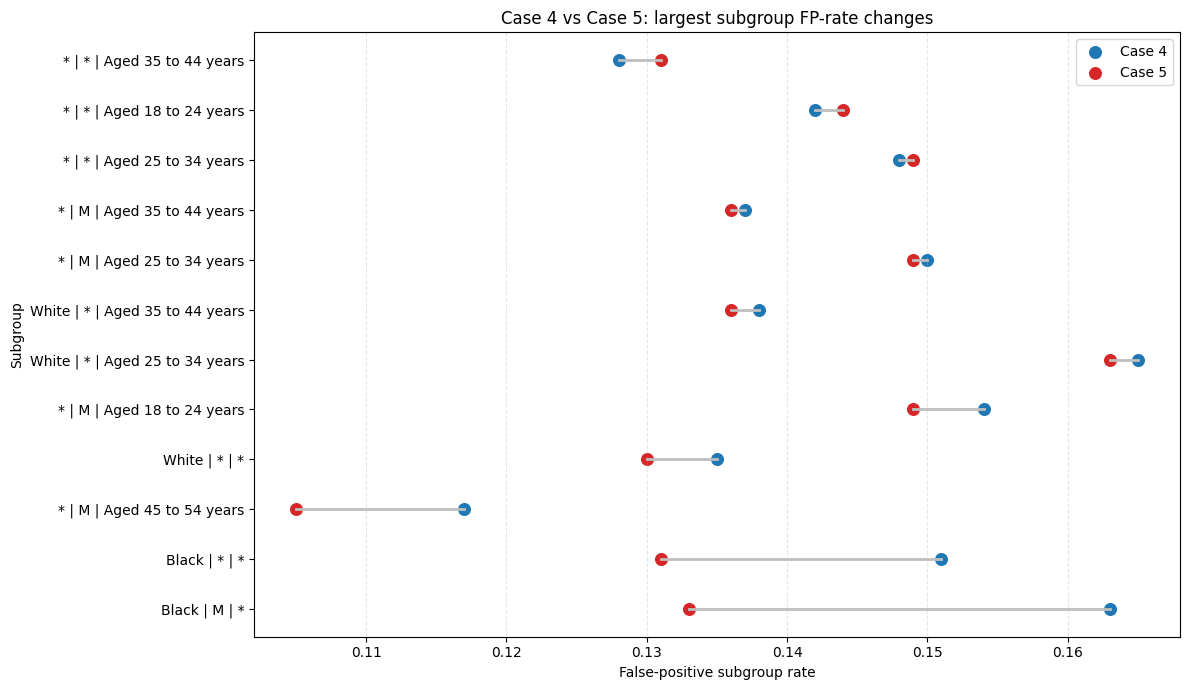

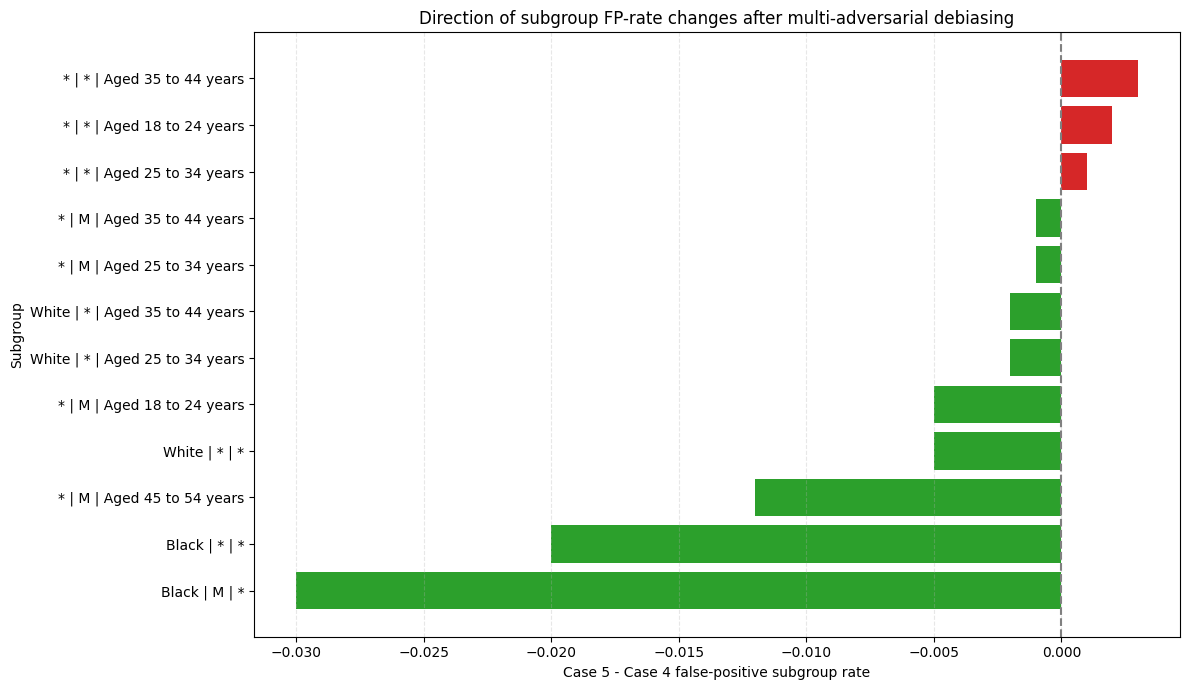

Case 4 vs Case 5 fairness summary


,case,attribute,accuracy,f1,roc_auc,TPR_gap,FPR_gap,FNR_gap,SelectionRate_gap,EO_gap_max
0,Case 4 one-hot + ord-encoded + one-hot + SMOTE...,Perceived_Race,0.840350,0.521198,0.882426,0.494048,0.105245,0.494048,0.167809,0.494048
1,Case 5 one-hot + ord-encoded + one-hot + SMOTE...,Perceived_Race,0.840274,0.520857,0.881296,0.170918,0.049345,0.170918,0.082992,0.170918
2,Case 4 one-hot + ord-encoded + one-hot + SMOTE...,Race_Sex_intersection,0.840350,0.521198,0.882426,0.645626,0.192260,0.645626,0.248790,0.645626
3,Case 5 one-hot + ord-encoded + one-hot + SMOTE...,Race_Sex_intersection,0.840274,0.520857,0.881296,0.500000,0.125807,0.500000,0.172638,0.500000
4,Case 4 one-hot + ord-encoded + one-hot + SMOTE...,Sex,0.840350,0.521198,0.882426,0.091438,0.040385,0.091438,0.055432,0.091438
5,Case 5 one-hot + ord-encoded + one-hot + SMOTE...,Sex,0.840274,0.520857,0.881296,0.046004,0.017845,0.046004,0.030382,0.046004


Race-level Case 4 vs Case 5 comparison


,group,count_case4,TPR_case4,TPR_case5,TPR_delta,FPR_case4,FPR_case5,FPR_delta,FNR_case4,FNR_case5,FNR_delta
1,Black,3464,0.764826,0.693252,-0.071575,0.176134,0.152269,-0.023866,0.235174,0.306748,0.071575
3,East/Southeast Asian,839,0.562500,0.625000,0.062500,0.077419,0.107097,0.029677,0.437500,0.375000,-0.062500
6,Indigenous,392,0.785714,0.785714,0.000000,0.127976,0.122024,-0.005952,0.214286,0.214286,0.000000
7,Latino,350,0.291667,0.625000,0.333333,0.076687,0.156442,0.079755,0.708333,0.375000,-0.333333
5,Middle-Eastern,623,0.425532,0.659574,0.234043,0.072917,0.131944,0.059028,0.574468,0.340426,-0.234043
4,South Asian,712,0.612245,0.795918,0.183673,0.070890,0.129713,0.058824,0.387755,0.204082,-0.183673
2,Unknown or Legacy,1135,0.694444,0.666667,-0.027778,0.162610,0.142162,-0.020448,0.305556,0.333333,0.027778
0,White,5501,0.753804,0.760719,0.006916,0.155086,0.149226,-0.005860,0.246196,0.239281,-0.006916


Sex-level Case 4 vs Case 5 comparison


,group,count_case4,TPR_case4,TPR_case5,TPR_delta,FPR_case4,FPR_case5,FPR_delta,FNR_case4,FNR_case5,FNR_delta
1,F,2539,0.649446,0.686347,0.036900,0.111552,0.129630,0.018078,0.350554,0.313653,-0.036900
0,M,10477,0.740884,0.732351,-0.008534,0.151937,0.147475,-0.004462,0.259116,0.267649,0.008534


Intersection-level Case 4 vs Case 5 comparison


,group,count_case4,TPR_case4,TPR_case5,TPR_delta,FPR_case4,FPR_case5,FPR_delta,FNR_case4,FNR_case5,FNR_delta
0,White | M,4273,0.775769,0.772152,-0.003617,0.156183,0.147581,-0.008602,0.224231,0.227848,0.003617
1,Black | M,2864,0.783908,0.708046,-0.075862,0.192260,0.156443,-0.035817,0.216092,0.291954,0.075862
2,White | F,1228,0.682353,0.723529,0.041176,0.151229,0.155009,0.003781,0.317647,0.276471,-0.041176
3,Unknown or Legacy | M,936,0.677419,0.645161,-0.032258,0.185053,0.155397,-0.029656,0.322581,0.354839,0.032258
4,East/Southeast Asian | M,695,0.586207,0.637931,0.051724,0.084772,0.117739,0.032967,0.413793,0.362069,-0.051724
5,South Asian | M,610,0.613636,0.772727,0.159091,0.079505,0.134276,0.054770,0.386364,0.227273,-0.159091
6,Black | F,600,0.611111,0.574074,-0.037037,0.104396,0.133700,0.029304,0.388889,0.425926,0.037037
7,Middle-Eastern | M,552,0.428571,0.666667,0.238095,0.074510,0.135294,0.060784,0.571429,0.333333,-0.238095
8,Latino | M,290,0.238095,0.619048,0.380952,0.092937,0.178439,0.085502,0.761905,0.380952,-0.380952
9,Indigenous | M,257,0.883721,0.860465,-0.023256,0.140187,0.126168,-0.014019,0.116279,0.139535,0.023256


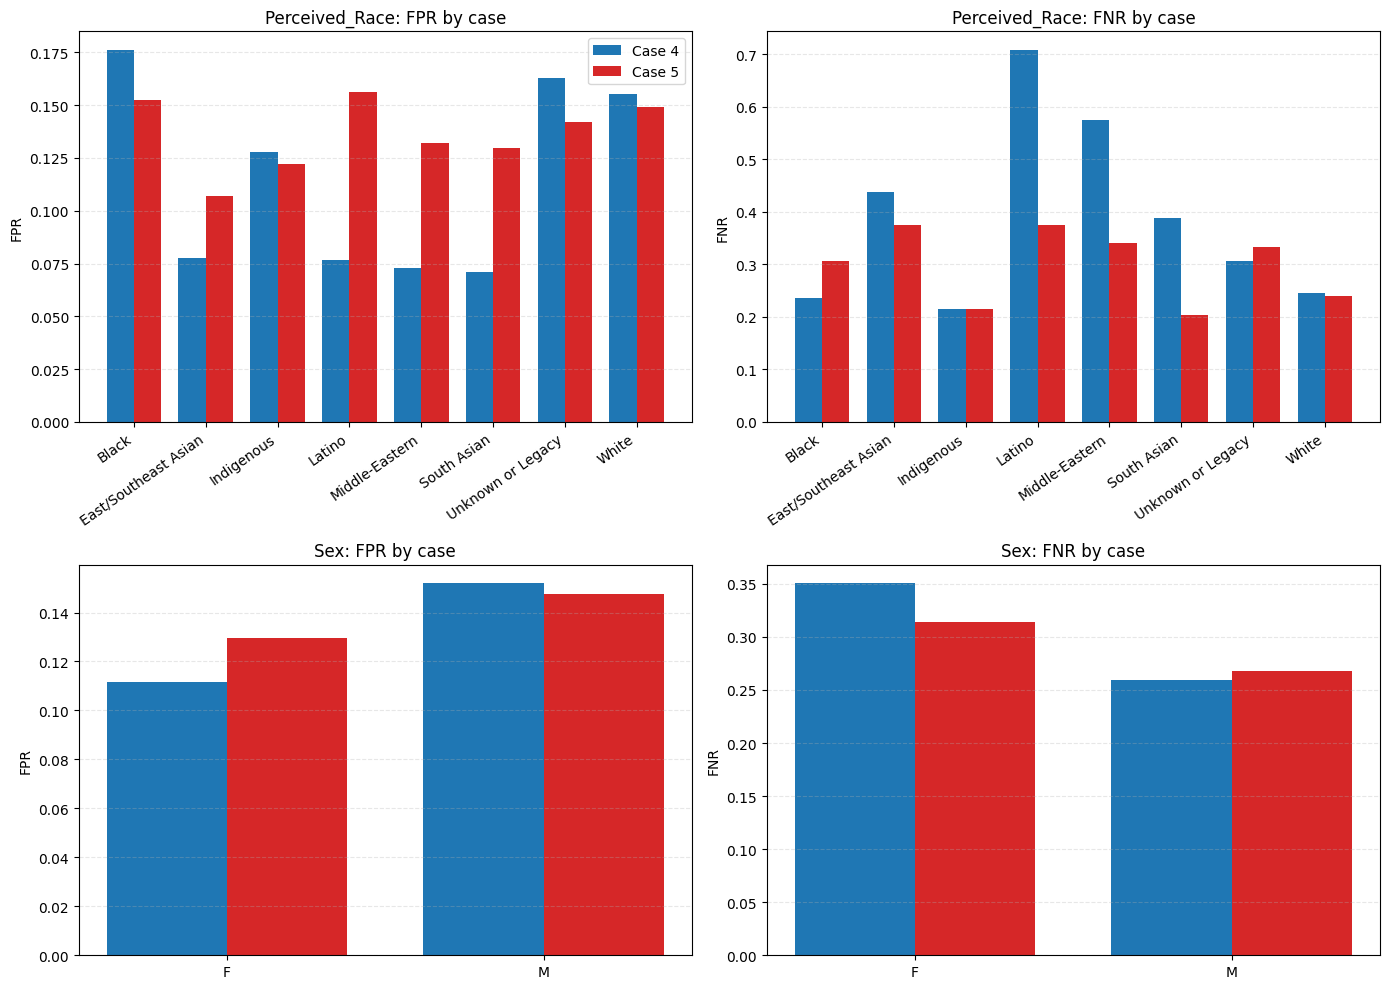

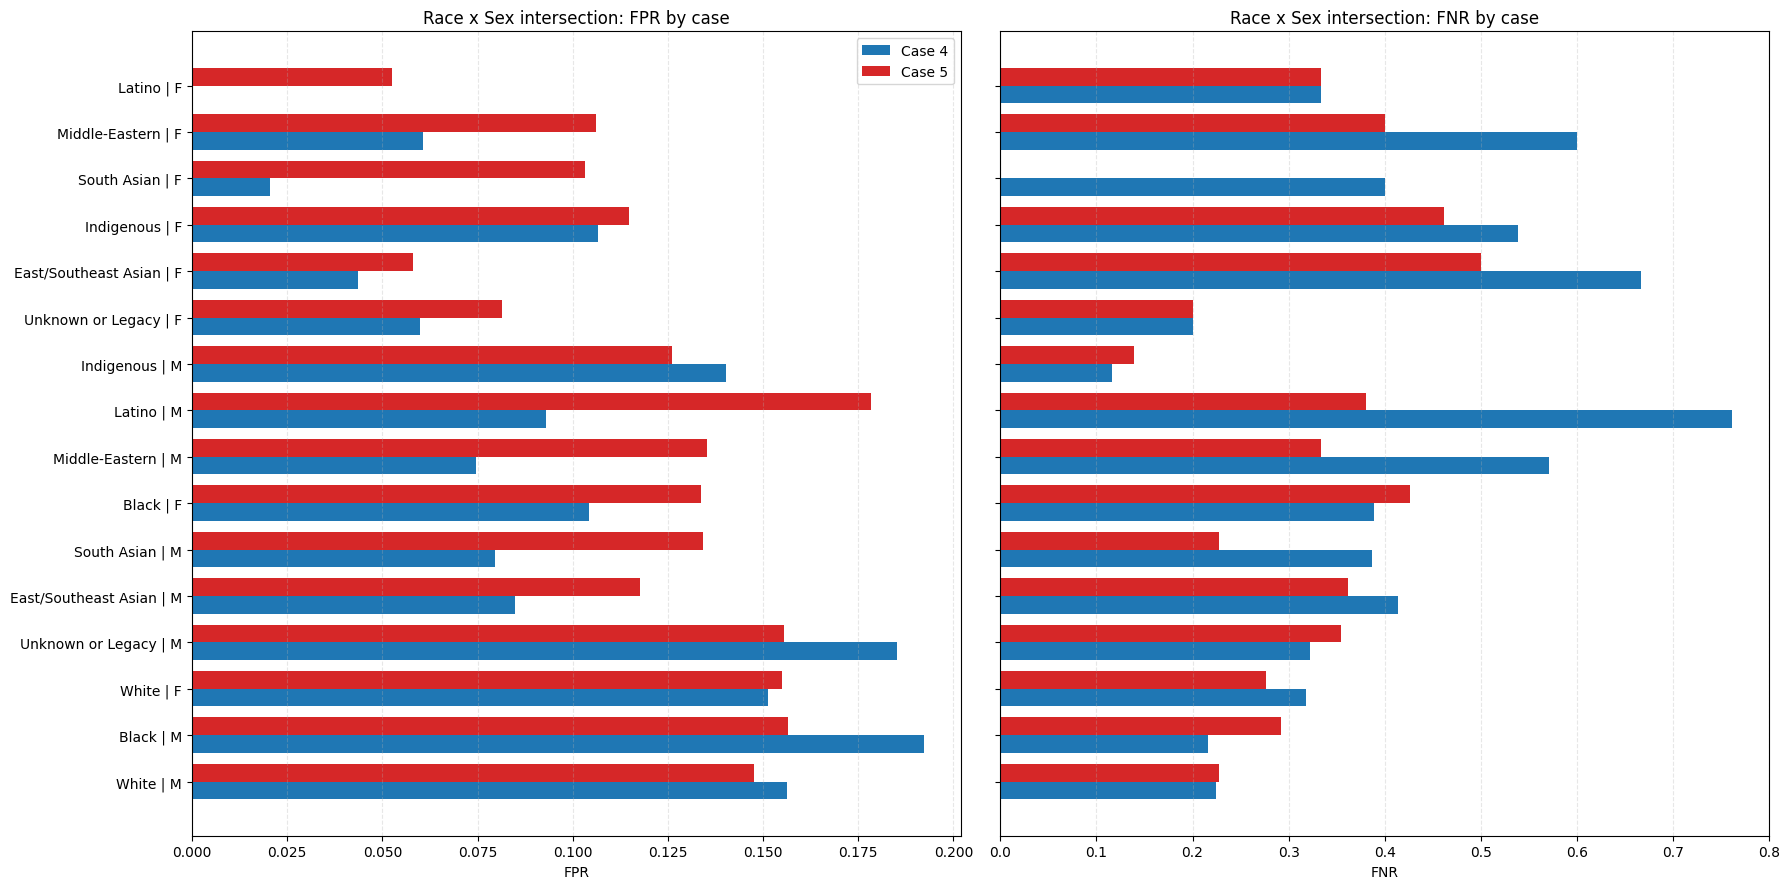

In [21]:
def decode_exp_table_labels(df_in, encoders_map, custom_map=None):
    out = df_in.copy()
    custom_map = custom_map or {}

    for col, le in encoders_map.items():
        if col not in out.columns:
            continue
        inv = {i: v for i, v in enumerate(le.classes_)}

        def decode_value(x):
            if pd.isna(x) or x == "*":
                return x
            try:
                return inv.get(int(float(x)), x)
            except (ValueError, TypeError):
                return x

        out[col] = out[col].apply(decode_value)

    for col, mapping in custom_map.items():
        if col not in out.columns:
            continue

        def decode_custom_value(x):
            if pd.isna(x) or x == "*":
                return x
            try:
                return mapping.get(int(float(x)), x)
            except (ValueError, TypeError):
                return x

        out[col] = out[col].apply(decode_custom_value)

    return out

def pretty_subgroup_label(row):
    return f"{row['Perceived_Race']} | {row['Sex']} | {row['Age_group__at_arrest_']}"

comparison_fp = sorted_fp_case4.merge(
    sorted_fp_case5,
    on=group_cols,
    how="outer",
    suffixes=("_case4", "_case5")
)
comparison_fp["present_case4"] = comparison_fp["support_case4"].notna()
comparison_fp["present_case5"] = comparison_fp["support_case5"].notna()
comparison_fp["fp_rate_delta"] = comparison_fp["targetcol_case5"] - comparison_fp["targetcol_case4"]
comparison_fp["abs_fp_rate_delta"] = comparison_fp["fp_rate_delta"].abs()
comparison_fp = comparison_fp.sort_values(
    by=["abs_fp_rate_delta", "support_case5", "support_case4"],
    ascending=[False, False, False],
    na_position="last"
)

comparison_fp_pretty = decode_exp_table_labels(comparison_fp, encoders, custom_encoders)
comparison_fp_pretty = comparison_fp_pretty.rename(columns={
    "targetcol_case4": "fp_rate_case4",
    "targetcol_case5": "fp_rate_case5",
})
comparison_fp_pretty["subgroup"] = comparison_fp_pretty.apply(pretty_subgroup_label, axis=1)

print("Case 4 vs Case 5 false-positive subgroup rates (outer join, so unique subgroups are kept; NA means the pattern was not returned in that case's explanation table)")
display(comparison_fp_pretty[["subgroup", "present_case4", "present_case5", "support_case4", "support_case5", "fp_rate_case4", "fp_rate_case5", "fp_rate_delta"]])

comparison_fp_overlap = comparison_fp_pretty[
    comparison_fp_pretty["present_case4"] & comparison_fp_pretty["present_case5"]
].copy()
top_delta = comparison_fp_overlap.sort_values("abs_fp_rate_delta", ascending=False).head(12).copy()
top_delta = top_delta.sort_values("fp_rate_delta")

plt.figure(figsize=(12, 7))
for _, row in top_delta.iterrows():
    plt.plot([row['fp_rate_case4'], row['fp_rate_case5']], [row['subgroup'], row['subgroup']], color='0.75', linewidth=2)
plt.scatter(top_delta['fp_rate_case4'], top_delta['subgroup'], color='#1f77b4', s=70, label='Case 4')
plt.scatter(top_delta['fp_rate_case5'], top_delta['subgroup'], color='#d62728', s=70, label='Case 5')
plt.xlabel('False-positive subgroup rate')
plt.ylabel('Subgroup')
plt.title('Case 4 vs Case 5: largest subgroup FP-rate changes')
plt.grid(axis='x', linestyle='--', alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 7))
bar_colors = ['#d62728' if x > 0 else '#2ca02c' for x in top_delta['fp_rate_delta']]
plt.barh(top_delta['subgroup'], top_delta['fp_rate_delta'], color=bar_colors)
plt.axvline(0, color='gray', linestyle='--')
plt.xlabel('Case 5 - Case 4 false-positive subgroup rate')
plt.ylabel('Subgroup')
plt.title('Direction of subgroup FP-rate changes after multi-adversarial debiasing')
plt.grid(axis='x', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

# Direct protected-attribute comparison from the readable group tables
def compare_group_metric(case4_tbl, case5_tbl):
    merged = case4_tbl.merge(case5_tbl, on='group', suffixes=('_case4', '_case5'))
    for metric in ['count', 'TPR', 'FPR', 'FNR', 'SelectionRate']:
        merged[f'{metric}_delta'] = merged[f'{metric}_case5'] - merged[f'{metric}_case4']
    return merged

case45_summary = summary_df[summary_df['case'].isin([case4_name, case5_name])].copy()
case45_summary = case45_summary.sort_values(['attribute', 'case']).reset_index(drop=True)
print('Case 4 vs Case 5 fairness summary')
display(case45_summary[['case', 'attribute', 'accuracy', 'f1', 'roc_auc', 'TPR_gap', 'FPR_gap', 'FNR_gap', 'SelectionRate_gap', 'EO_gap_max']])

race_compare = compare_group_metric(group_tables[(case4_name, 'Perceived_Race')], group_tables[(case5_name, 'Perceived_Race')])
sex_compare = compare_group_metric(group_tables[(case4_name, 'Sex')], group_tables[(case5_name, 'Sex')])
intersection_compare = compare_group_metric(group_tables[(case4_name, 'Race_Sex_intersection')], group_tables[(case5_name, 'Race_Sex_intersection')])

print('Race-level Case 4 vs Case 5 comparison')
display(race_compare[['group', 'count_case4', 'TPR_case4', 'TPR_case5', 'TPR_delta', 'FPR_case4', 'FPR_case5', 'FPR_delta', 'FNR_case4', 'FNR_case5', 'FNR_delta']].sort_values('group'))
print('Sex-level Case 4 vs Case 5 comparison')
display(sex_compare[['group', 'count_case4', 'TPR_case4', 'TPR_case5', 'TPR_delta', 'FPR_case4', 'FPR_case5', 'FPR_delta', 'FNR_case4', 'FNR_case5', 'FNR_delta']].sort_values('group'))
print('Intersection-level Case 4 vs Case 5 comparison')
display(intersection_compare[['group', 'count_case4', 'TPR_case4', 'TPR_case5', 'TPR_delta', 'FPR_case4', 'FPR_case5', 'FPR_delta', 'FNR_case4', 'FNR_case5', 'FNR_delta']].sort_values('count_case4', ascending=False))

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
race_plot = race_compare.sort_values('group').copy()
sex_plot = sex_compare.sort_values('group').copy()
race_idx = np.arange(len(race_plot))
sex_idx = np.arange(len(sex_plot))
width = 0.38

axes[0, 0].bar(race_idx - width/2, race_plot['FPR_case4'], width, label='Case 4', color='#1f77b4')
axes[0, 0].bar(race_idx + width/2, race_plot['FPR_case5'], width, label='Case 5', color='#d62728')
axes[0, 0].set_title('Perceived_Race: FPR by case')
axes[0, 0].set_xticks(race_idx)
axes[0, 0].set_xticklabels(race_plot['group'], rotation=35, ha='right')
axes[0, 0].set_ylabel('FPR')
axes[0, 0].legend()

axes[0, 1].bar(race_idx - width/2, race_plot['FNR_case4'], width, label='Case 4', color='#1f77b4')
axes[0, 1].bar(race_idx + width/2, race_plot['FNR_case5'], width, label='Case 5', color='#d62728')
axes[0, 1].set_title('Perceived_Race: FNR by case')
axes[0, 1].set_xticks(race_idx)
axes[0, 1].set_xticklabels(race_plot['group'], rotation=35, ha='right')
axes[0, 1].set_ylabel('FNR')

axes[1, 0].bar(sex_idx - width/2, sex_plot['FPR_case4'], width, label='Case 4', color='#1f77b4')
axes[1, 0].bar(sex_idx + width/2, sex_plot['FPR_case5'], width, label='Case 5', color='#d62728')
axes[1, 0].set_title('Sex: FPR by case')
axes[1, 0].set_xticks(sex_idx)
axes[1, 0].set_xticklabels(sex_plot['group'])
axes[1, 0].set_ylabel('FPR')

axes[1, 1].bar(sex_idx - width/2, sex_plot['FNR_case4'], width, label='Case 4', color='#1f77b4')
axes[1, 1].bar(sex_idx + width/2, sex_plot['FNR_case5'], width, label='Case 5', color='#d62728')
axes[1, 1].set_title('Sex: FNR by case')
axes[1, 1].set_xticks(sex_idx)
axes[1, 1].set_xticklabels(sex_plot['group'])
axes[1, 1].set_ylabel('FNR')

for ax in axes.flat:
    ax.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

intersection_plot = intersection_compare.sort_values('count_case4', ascending=False).copy()
intersection_y = np.arange(len(intersection_plot))
fig, axes = plt.subplots(1, 2, figsize=(18, 9), sharey=True)

axes[0].barh(intersection_y - width/2, intersection_plot['FPR_case4'], height=width, color='#1f77b4', label='Case 4')
axes[0].barh(intersection_y + width/2, intersection_plot['FPR_case5'], height=width, color='#d62728', label='Case 5')
axes[0].set_title('Race x Sex intersection: FPR by case')
axes[0].set_yticks(intersection_y)
axes[0].set_yticklabels(intersection_plot['group'])
axes[0].set_xlabel('FPR')
axes[0].grid(axis='x', linestyle='--', alpha=0.3)
axes[0].legend()

axes[1].barh(intersection_y - width/2, intersection_plot['FNR_case4'], height=width, color='#1f77b4', label='Case 4')
axes[1].barh(intersection_y + width/2, intersection_plot['FNR_case5'], height=width, color='#d62728', label='Case 5')
axes[1].set_title('Race x Sex intersection: FNR by case')
axes[1].set_yticks(intersection_y)
axes[1].set_yticklabels(intersection_plot['group'])
axes[1].set_xlabel('FNR')
axes[1].grid(axis='x', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()


### Case5.x ablation

In [22]:
exp_mod = globals().get("exptb", globals().get("exptbl"))
if exp_mod is None:
    raise NameError("Neither exptb nor exptbl is available. Import exp as exptb first.")

CASE5X_EXPLAIN_DIR = os.path.join(CASE5X_EXT_DIR, "explanations")
os.makedirs(CASE5X_EXPLAIN_DIR, exist_ok=True)

min_sup = 0.1
group_cols = ["Perceived_Race", "Sex", "Age_group__at_arrest_"]
exp_table_cols = group_cols + ["targetcol"]

X_train_exp = X_train.copy(deep=True)
X_test_exp = X_test.copy(deep=True)

encoders = {}
for col in group_cols:
    le = LabelEncoder()
    X_train_exp[col] = le.fit_transform(X_train_exp[col].astype(str))
    mapping = {v: i for i, v in enumerate(le.classes_)}
    X_test_exp[col] = X_test_exp[col].astype(str).map(mapping).fillna(-1).astype(int)
    encoders[col] = le


def build_fp_explanation_for_case(case_name, case_tag, top_k=12):
    y_pred_local = results[case_name]["y_pred"]
    y_true_local = y_test.copy().reset_index(drop=True).astype(int)

    x_res_fp = label_false_positives(X_test_exp, y_true_local, y_pred_local)

    temp_case_fp_path = os.path.join(FP_DIR, f"temp_{case_tag}_fp.csv")
    target_case_fp_path = os.path.join(FP_DIR, f"target_{case_tag}_fp.csv")

    x_res_fp[exp_table_cols].to_csv(temp_case_fp_path, index=False)
    pd.DataFrame().to_csv(target_case_fp_path, index=False)

    res_fp = exp_mod.calculate_table(
        target_case_fp_path,
        temp_case_fp_path,
        target_case_fp_path,
        min_support_param=min_sup,
    )
    fp_exp = pd.read_csv(res_fp, sep=';')
    sorted_fp = fp_exp.sort_values(by=["targetcol"], ascending=[False]).reset_index(drop=True)

    decoded_fp = decode_exp_table_labels(sorted_fp, encoders, custom_map={})

    full_csv = os.path.join(CASE5X_EXPLAIN_DIR, f"{case_tag}_fp_table_full.csv")
    top_csv = os.path.join(CASE5X_EXPLAIN_DIR, f"{case_tag}_fp_table_top{top_k}.csv")
    decoded_fp.to_csv(full_csv, index=False)
    decoded_fp.head(top_k).to_csv(top_csv, index=False)

    return decoded_fp, temp_case_fp_path, target_case_fp_path, full_csv, top_csv

#### Case 5.1


In [23]:
fp_case51_df, temp_case51_fp_path, target_case51_fp_path, case51_full_csv, case51_top_csv = build_fp_explanation_for_case(case51_name, "case51")
print(case51_name)
print("temp:", temp_case51_fp_path)
print("target:", target_case51_fp_path)
print("full csv:", case51_full_csv)
print("top csv:", case51_top_csv)
display(fp_case51_df.head(12))



Compiling with commands:  ['g++', '/Users/om-college/Work/2 Canada/York/Winter26/Fairness and Bias in AI/Project/groupfairnessproject-local/exp/Explanations.cpp', '/Users/om-college/Work/2 Canada/York/Winter26/Fairness and Bias in AI/Project/groupfairnessproject-local/exp/Lighthouse.cpp', '-std=c++17', '-o', 'program', '-I/opt/homebrew/opt/boost/include']
Arguments to the program: baseline_nn_output/fp_analysis/target_case51_fp.csv baseline_nn_output/fp_analysis/temp_case51_fp.csv 3 15 0 baseline_nn_output/fp_analysis/target_case51_fp.csv 0.1
Time: 0:00:09.550695
Case 5.1 one-hot + ord-encoded + one-hot + SMOTE + multi-adversarial + age
temp: baseline_nn_output/fp_analysis/temp_case51_fp.csv
target: baseline_nn_output/fp_analysis/target_case51_fp.csv
full csv: baseline_nn_output/case5x_extension/explanations/case51_fp_table_full.csv
top csv: baseline_nn_output/case5x_extension/explanations/case51_fp_table_top12.csv


,Perceived_Race,Sex,Age_group__at_arrest_,targetcol,support
0,White,*,2,0.162,1687
1,*,M,1,0.147,1598
2,*,*,1,0.146,2012
3,*,*,2,0.143,4237
4,*,M,2,0.143,3378
5,White,*,3,0.138,1511
6,Black,M,*,0.137,2864
7,Black,*,*,0.135,3464
8,White,*,*,0.134,5501
9,*,M,3,0.133,2601


#### Case 5.2


In [24]:
fp_case52_df, temp_case52_fp_path, target_case52_fp_path, case52_full_csv, case52_top_csv = build_fp_explanation_for_case(case52_name, "case52")
print(case52_name)
print("temp:", temp_case52_fp_path)
print("target:", target_case52_fp_path)
print("full csv:", case52_full_csv)
print("top csv:", case52_top_csv)
display(fp_case52_df.head(12))



Compiling with commands:  ['g++', '/Users/om-college/Work/2 Canada/York/Winter26/Fairness and Bias in AI/Project/groupfairnessproject-local/exp/Explanations.cpp', '/Users/om-college/Work/2 Canada/York/Winter26/Fairness and Bias in AI/Project/groupfairnessproject-local/exp/Lighthouse.cpp', '-std=c++17', '-o', 'program', '-I/opt/homebrew/opt/boost/include']
Arguments to the program: baseline_nn_output/fp_analysis/target_case52_fp.csv baseline_nn_output/fp_analysis/temp_case52_fp.csv 3 15 0 baseline_nn_output/fp_analysis/target_case52_fp.csv 0.1
Time: 0:00:08.719830
Case 5.2 one-hot + ord-encoded + one-hot + SMOTE + multi-adversarial + age intersections
temp: baseline_nn_output/fp_analysis/temp_case52_fp.csv
target: baseline_nn_output/fp_analysis/target_case52_fp.csv
full csv: baseline_nn_output/case5x_extension/explanations/case52_fp_table_full.csv
top csv: baseline_nn_output/case5x_extension/explanations/case52_fp_table_top12.csv


,Perceived_Race,Sex,Age_group__at_arrest_,targetcol,support
0,*,M,1,0.158,1598
1,White,*,2,0.157,1687
2,*,*,1,0.154,2012
3,*,M,2,0.149,3378
4,*,*,2,0.146,4237
5,*,M,*,0.144,10477
6,Black,M,*,0.141,2864
7,*,M,3,0.139,2601
8,Black,*,*,0.139,3464
9,*,*,*,0.138,13016


#### Case5.3

In [25]:
fp_case53_df, temp_case53_fp_path, target_case53_fp_path, case53_full_csv, case53_top_csv = build_fp_explanation_for_case(case53_name, "case53")
print(case53_name)
print("temp:", temp_case53_fp_path)
print("target:", target_case53_fp_path)
print("full csv:", case53_full_csv)
print("top csv:", case53_top_csv)
display(fp_case53_df.head(12))



Compiling with commands:  ['g++', '/Users/om-college/Work/2 Canada/York/Winter26/Fairness and Bias in AI/Project/groupfairnessproject-local/exp/Explanations.cpp', '/Users/om-college/Work/2 Canada/York/Winter26/Fairness and Bias in AI/Project/groupfairnessproject-local/exp/Lighthouse.cpp', '-std=c++17', '-o', 'program', '-I/opt/homebrew/opt/boost/include']
Arguments to the program: baseline_nn_output/fp_analysis/target_case53_fp.csv baseline_nn_output/fp_analysis/temp_case53_fp.csv 3 15 0 baseline_nn_output/fp_analysis/target_case53_fp.csv 0.1
Time: 0:00:09.629121
Case 5.3 one-hot + ord-encoded + one-hot + SMOTE + multi-adversarial + three-way age intersection
temp: baseline_nn_output/fp_analysis/temp_case53_fp.csv
target: baseline_nn_output/fp_analysis/target_case53_fp.csv
full csv: baseline_nn_output/case5x_extension/explanations/case53_fp_table_full.csv
top csv: baseline_nn_output/case5x_extension/explanations/case53_fp_table_top12.csv


,Perceived_Race,Sex,Age_group__at_arrest_,targetcol,support
0,*,M,1,0.158,1598
1,White,*,2,0.156,1687
2,*,*,1,0.155,2012
3,*,*,2,0.144,4237
4,Black,*,*,0.143,3464
5,Black,M,*,0.142,2864
6,*,M,2,0.140,3378
7,*,M,*,0.134,10477
8,White,*,*,0.134,5501
9,*,*,*,0.133,13016


#### Case 5 vs Case 5.x comparison


Utility comparison (Case 5 vs 5.x)


,case,label,accuracy,f1,roc_auc
3,Case 5.3 one-hot + ord-encoded + one-hot + SMO...,Case 5.3,0.835433,0.518652,0.883094
0,Case 5 one-hot + ord-encoded + one-hot + SMOTE...,Case 5,0.840274,0.520857,0.881296
2,Case 5.2 one-hot + ord-encoded + one-hot + SMO...,Case 5.2,0.831131,0.514147,0.881270
1,Case 5.1 one-hot + ord-encoded + one-hot + SMO...,Case 5.1,0.839121,0.516844,0.880744


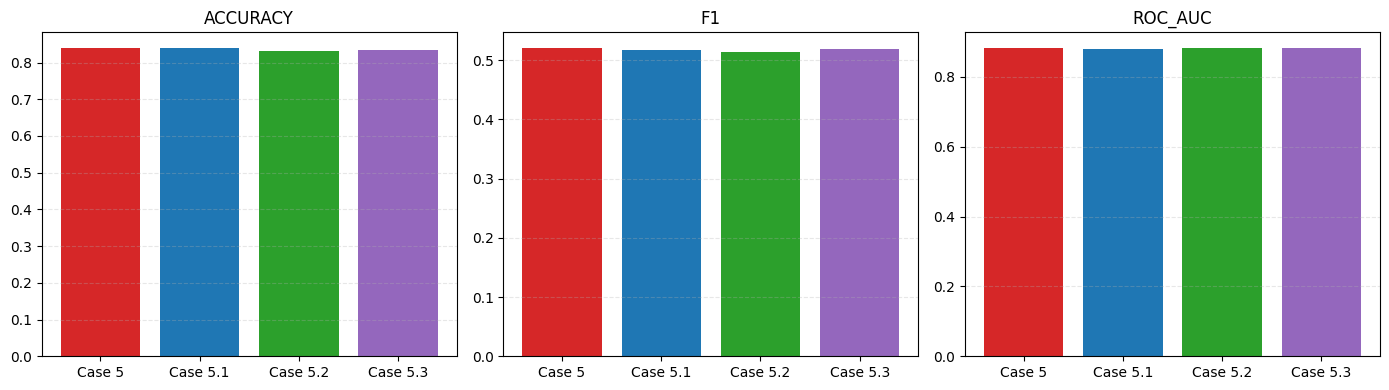

All-attribute fairness comparison (includes age intersections + three-way)


,case,attribute,FPR_gap,FNR_gap,SelectionRate_gap,EO_gap_max
0,Case 5.2 one-hot + ord-encoded + one-hot + SMO...,Age_group__at_arrest_,0.074875,0.125887,0.132217,0.125887
1,Case 5.1 one-hot + ord-encoded + one-hot + SMO...,Age_group__at_arrest_,0.131761,0.144427,0.187892,0.144427
3,Case 5.3 one-hot + ord-encoded + one-hot + SMO...,Age_group__at_arrest_,0.091398,0.180308,0.149145,0.180308
4,Case 5 one-hot + ord-encoded + one-hot + SMOTE...,Age_group__at_arrest_,0.141652,0.261905,0.207682,0.261905
5,Case 5 one-hot + ord-encoded + one-hot + SMOTE...,Perceived_Race,0.049345,0.170918,0.082992,0.170918
6,Case 5.2 one-hot + ord-encoded + one-hot + SMO...,Perceived_Race,0.070497,0.238095,0.059883,0.238095
7,Case 5.1 one-hot + ord-encoded + one-hot + SMO...,Perceived_Race,0.075808,0.254252,0.104206,0.254252
8,Case 5.3 one-hot + ord-encoded + one-hot + SMO...,Perceived_Race,0.060244,0.422619,0.099355,0.422619
10,Case 5 one-hot + ord-encoded + one-hot + SMOTE...,Race_Age_intersection,0.232558,1.000000,0.333333,1.000000
12,Case 5.3 one-hot + ord-encoded + one-hot + SMO...,Race_Age_intersection,0.333333,1.000000,0.333333,1.000000


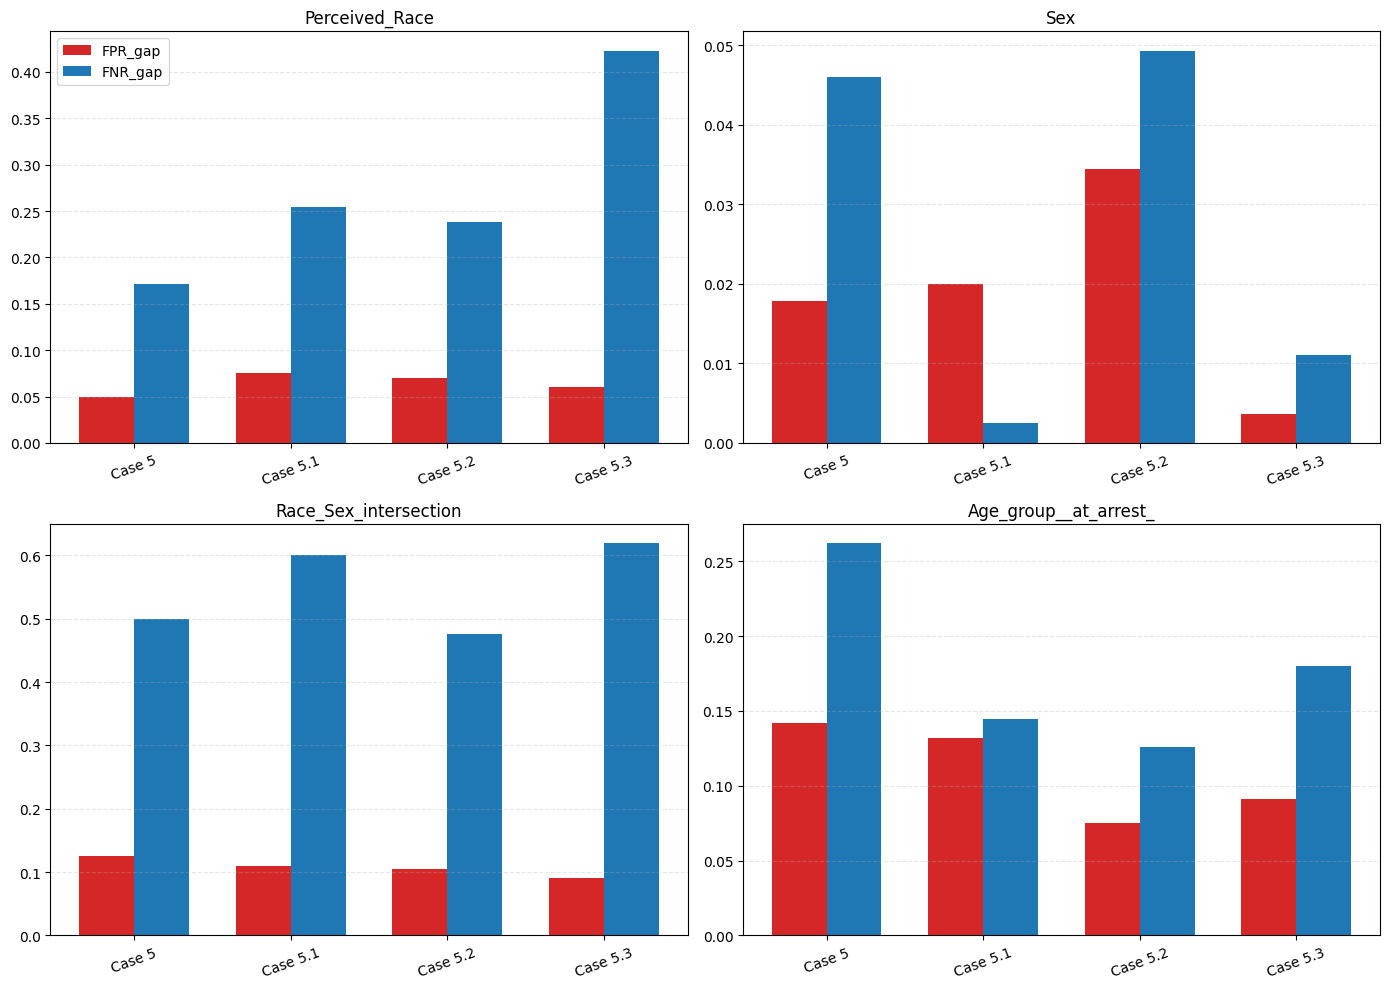

Subgroup visualizations (core attributes)


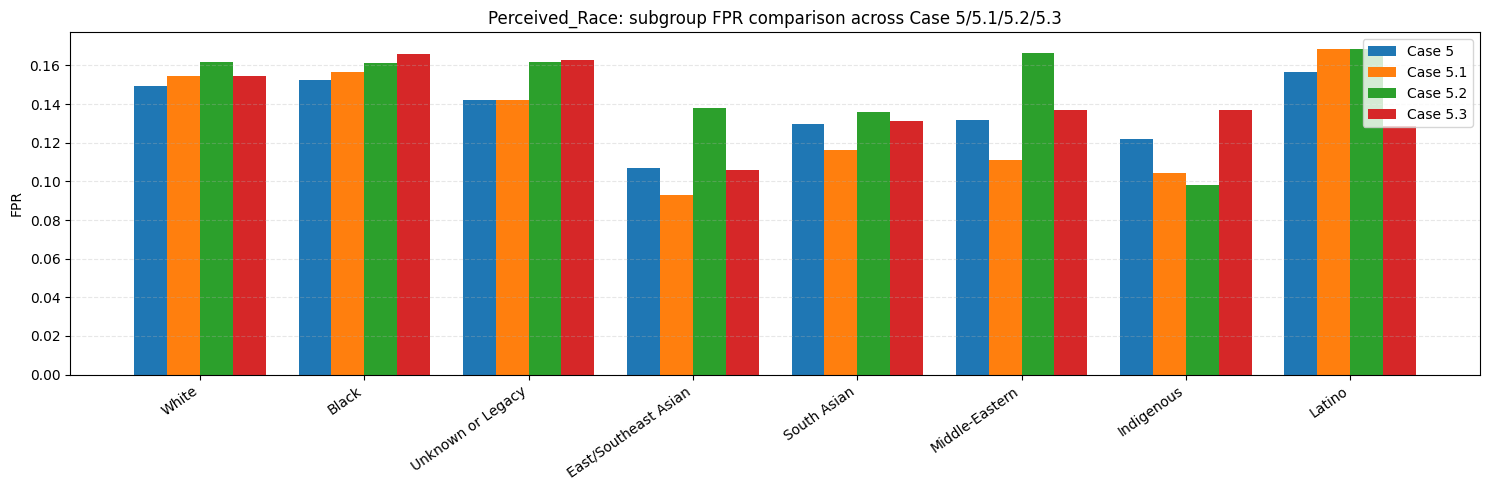

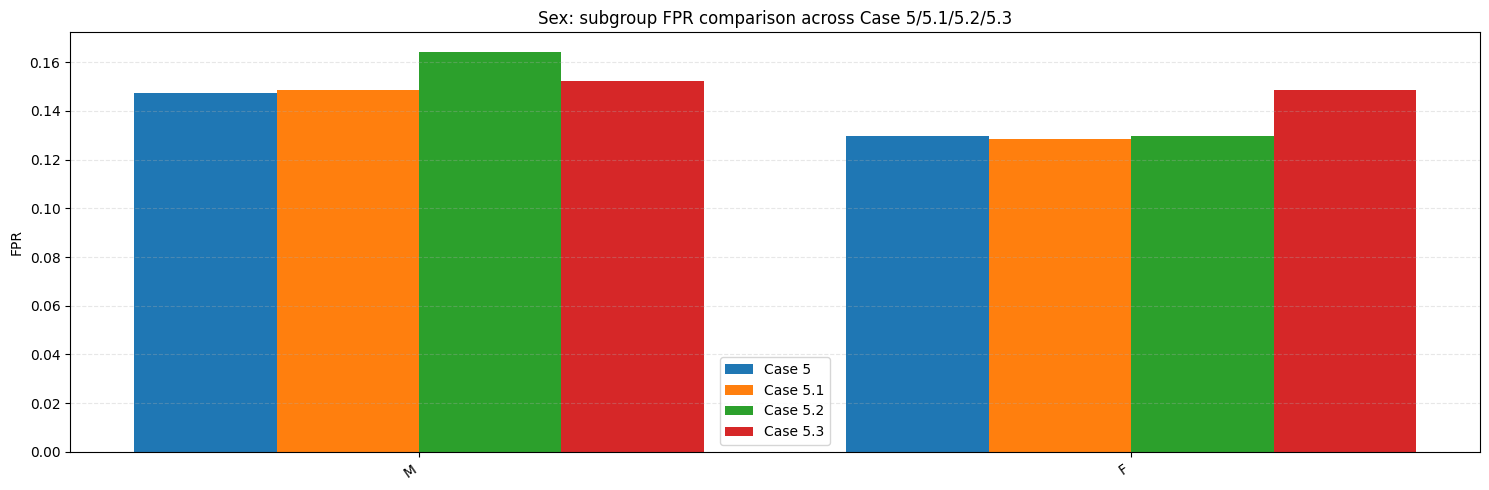

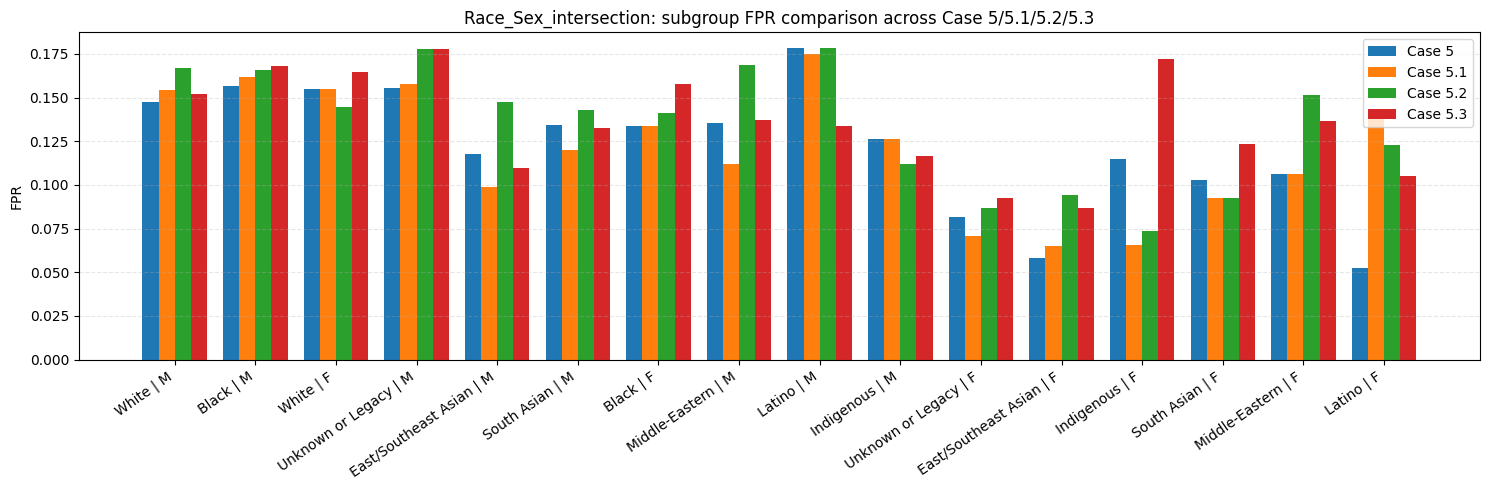

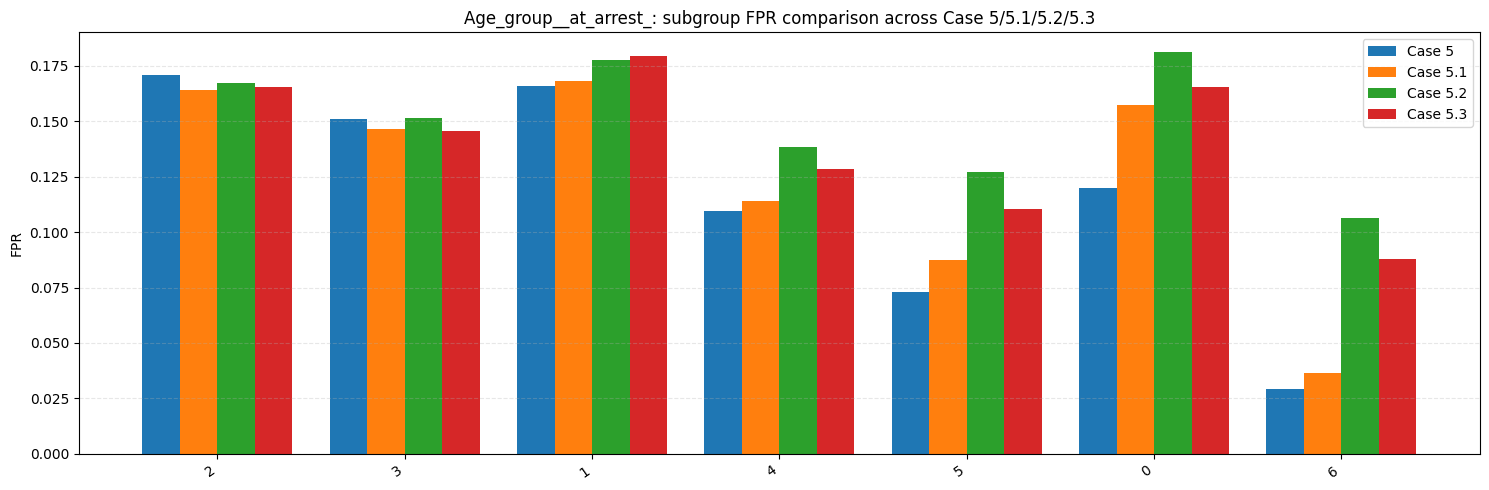

Subgroup visualizations (complex intersections, support-filtered)


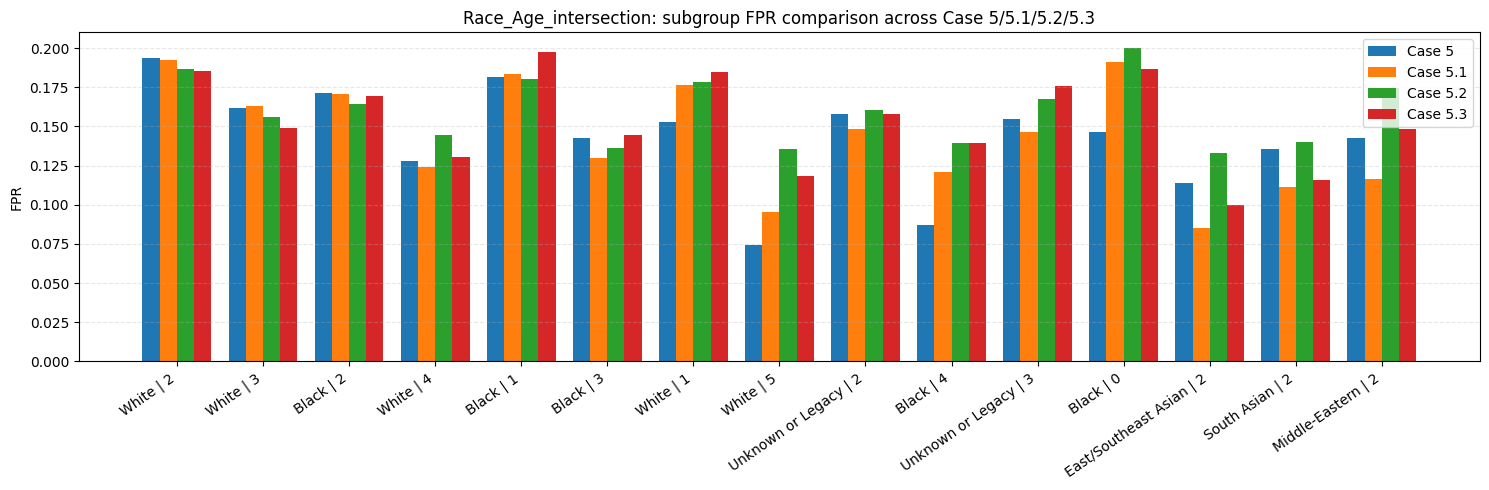

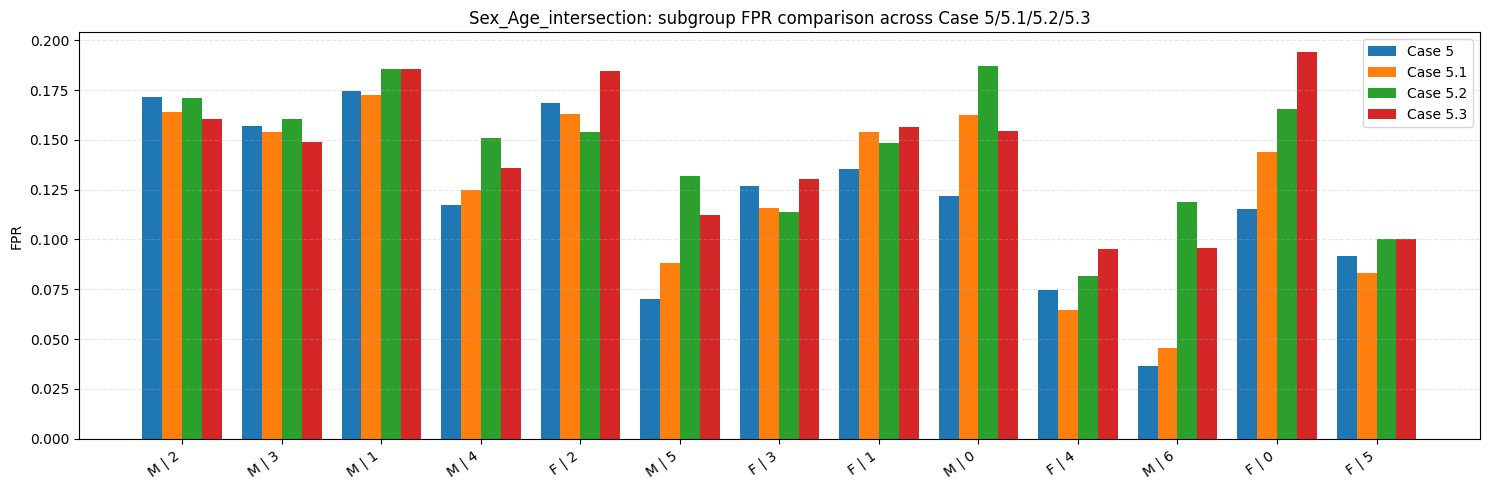

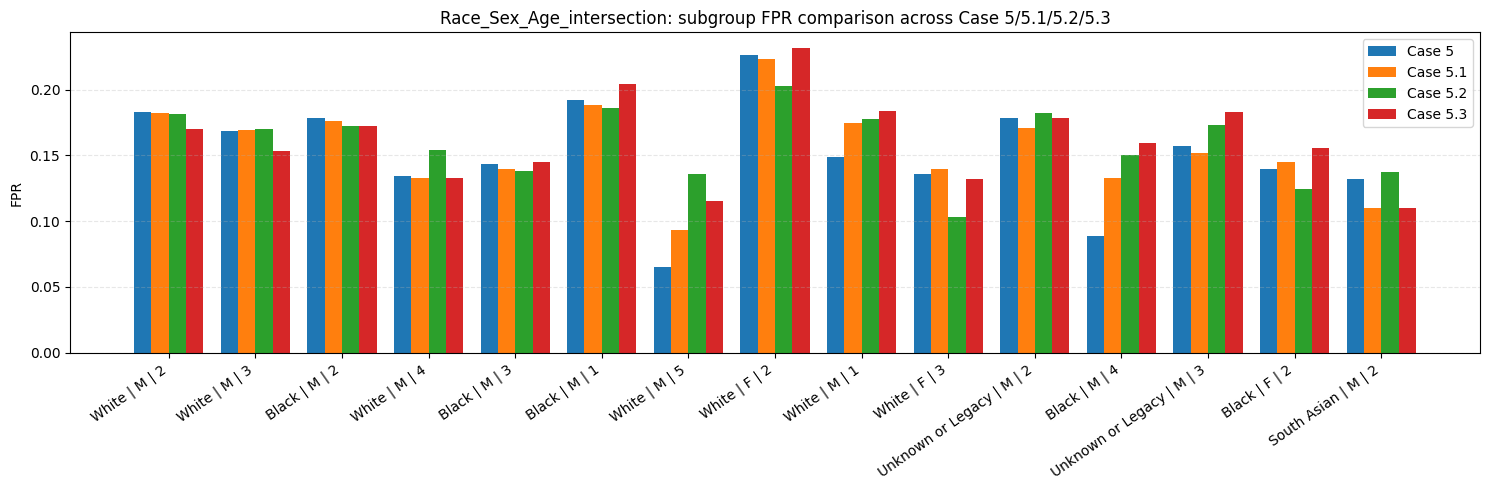

Exported extension artifacts to: baseline_nn_output/case5x_extension


In [26]:
compare_case_names = [case5_name_5x, case51_name, case52_name, case53_name]
compare_case_labels = ["Case 5", "Case 5.1", "Case 5.2", "Case 5.3"]

utility_compare_df = pd.DataFrame([
    {
        "case": name,
        "label": label,
        "accuracy": results[name]["accuracy"],
        "f1": results[name]["f1"],
        "roc_auc": results[name]["roc_auc"],
    }
    for name, label in zip(compare_case_names, compare_case_labels)
])

utility_compare_df.to_csv(
    os.path.join(CASE5X_EXT_DIR, "utility_case5_vs_5x.csv"),
    index=False,
)

print("Utility comparison (Case 5 vs 5.x)")
display(utility_compare_df.sort_values("roc_auc", ascending=False))

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, metric in zip(axes, ["accuracy", "f1", "roc_auc"]):
    ax.bar(utility_compare_df["label"], utility_compare_df[metric], color=["#d62728", "#1f77b4", "#2ca02c", "#9467bd"])
    ax.set_title(metric.upper())
    ax.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

gap_compare_df = case5_family_summary_df[
    case5_family_summary_df["case"].isin(compare_case_names)
].copy()

all_attrs_compare = [
    "Perceived_Race",
    "Sex",
    "Race_Sex_intersection",
    "Age_group__at_arrest_",
    "Race_Age_intersection",
    "Sex_Age_intersection",
    "Race_Sex_Age_intersection",
]

gap_compare_all_df = gap_compare_df[
    gap_compare_df["attribute"].isin(all_attrs_compare)
].copy()

gap_compare_all_df.to_csv(
    os.path.join(CASE5X_EXT_DIR, "fairness_case5_vs_5x_all_attrs.csv"),
    index=False,
)

print("All-attribute fairness comparison (includes age intersections + three-way)")
display(gap_compare_all_df[[
    "case", "attribute", "FPR_gap", "FNR_gap", "SelectionRate_gap", "EO_gap_max"
]].sort_values(["attribute", "EO_gap_max", "FPR_gap"]))

# Core-attribute focused chart for readability.
key_attrs_compare = [
    "Perceived_Race",
    "Sex",
    "Race_Sex_intersection",
    "Age_group__at_arrest_",
]
gap_compare_core_df = gap_compare_all_df[
    gap_compare_all_df["attribute"].isin(key_attrs_compare)
].copy()

gap_compare_core_df.to_csv(
    os.path.join(CASE5X_EXT_DIR, "fairness_case5_vs_5x_core_attrs.csv"),
    index=False,
)

fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharey=False)
axes = axes.reshape(-1)
bar_w = 0.35
x = np.arange(len(compare_case_labels))

for idx, attr in enumerate(key_attrs_compare):
    ax = axes[idx]
    sub = gap_compare_core_df[gap_compare_core_df["attribute"] == attr].set_index("case").reindex(compare_case_names)
    ax.bar(x - bar_w/2, sub["FPR_gap"].to_numpy(), bar_w, label="FPR_gap", color="#d62728")
    ax.bar(x + bar_w/2, sub["FNR_gap"].to_numpy(), bar_w, label="FNR_gap", color="#1f77b4")
    ax.set_xticks(x)
    ax.set_xticklabels(compare_case_labels, rotation=20)
    ax.set_title(attr)
    ax.grid(axis='y', linestyle='--', alpha=0.3)
axes[0].legend()
plt.tight_layout()
plt.show()


# Subgroup-level visualizations (similar spirit to Case4 vs Case5 section).
def subgroup_wide_table(attr, metric, min_support=0):
    merged = None
    support_ref = None
    for case_name, label in zip(compare_case_names, compare_case_labels):
        tbl = case5_family_group_tables[(case_name, attr)].copy()
        tbl = tbl[tbl["count"] >= min_support]
        if support_ref is None:
            support_ref = tbl[["group", "count"]].rename(columns={"count": "support_ref"})
        col_name = f"{metric}_{label.replace(' ', '_')}"
        tbl = tbl[["group", metric]].rename(columns={metric: col_name})
        merged = tbl if merged is None else merged.merge(tbl, on="group", how="outer")

    merged = merged.merge(support_ref, on="group", how="left") if support_ref is not None else merged
    return merged


def plot_subgroup_metric(attr, metric="FPR", min_support=0, top_k=12):
    wide = subgroup_wide_table(attr, metric=metric, min_support=min_support)
    wide = wide.sort_values("support_ref", ascending=False).head(top_k).copy()

    metric_cols = [f"{metric}_{lbl.replace(' ', '_')}" for lbl in compare_case_labels]
    x = np.arange(len(wide))
    width = 0.20

    plt.figure(figsize=(15, 5))
    for i, col in enumerate(metric_cols):
        plt.bar(x + (i - 1.5) * width, wide[col].to_numpy(), width=width, label=compare_case_labels[i])
    plt.xticks(x, wide["group"], rotation=35, ha='right')
    plt.ylabel(metric)
    plt.title(f"{attr}: subgroup {metric} comparison across Case 5/5.1/5.2/5.3")
    plt.grid(axis='y', linestyle='--', alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

    return wide

print("Subgroup visualizations (core attributes)")
core_viz_tables = {}
core_viz_tables["Perceived_Race"] = plot_subgroup_metric("Perceived_Race", metric="FPR", min_support=0, top_k=20)
core_viz_tables["Sex"] = plot_subgroup_metric("Sex", metric="FPR", min_support=0, top_k=10)
core_viz_tables["Race_Sex_intersection"] = plot_subgroup_metric("Race_Sex_intersection", metric="FPR", min_support=0, top_k=20)
core_viz_tables["Age_group__at_arrest_"] = plot_subgroup_metric("Age_group__at_arrest_", metric="FPR", min_support=0, top_k=20)

print("Subgroup visualizations (complex intersections, support-filtered)")
complex_viz_tables = {}
complex_viz_tables["Race_Age_intersection"] = plot_subgroup_metric("Race_Age_intersection", metric="FPR", min_support=COMPLEX_MIN_SUPPORT, top_k=15)
complex_viz_tables["Sex_Age_intersection"] = plot_subgroup_metric("Sex_Age_intersection", metric="FPR", min_support=COMPLEX_MIN_SUPPORT, top_k=15)
complex_viz_tables["Race_Sex_Age_intersection"] = plot_subgroup_metric("Race_Sex_Age_intersection", metric="FPR", min_support=COMPLEX_MIN_SUPPORT, top_k=15)

# Export subgroup tables used in visualizations.
for attr, tbl in {**core_viz_tables, **complex_viz_tables}.items():
    tbl.to_csv(
        os.path.join(CASE5X_EXT_DIR, f"subgroup_{attr}_fpr_case5_vs_5x.csv"),
        index=False,
    )

print("Exported extension artifacts to:", CASE5X_EXT_DIR)



Case 5: Acc 0.8403, F1 0.5209, AUC 0.8813 <br>
- 5.1: slight utility drop. <br>
- 5.2: clear utility drop (Acc 0.8311, F1 0.5141).<br>
- 5.3: best AUC (0.8831) but lower Acc/F1 than Case 5. <br><br>

Fairness tradeoffs: <br>
- 5.2 improves age EO gap strongly (0.2619 -> 0.1259) and slightly improves Race×Sex EO (0.500 -> 0.476), but worsens race EO (0.1709 -> 0.2381) and raises overall FP pressure in subgroup charts.
- 5.1 is mostly lateral/slightly worse overall.
- 5.3 improves sex EO but worsens race and race×sex EO gaps a lot.
- In intersection groups, EO gaps hits 1.0 across almsot all their cases, which gives unclear signals this might be becasue of sparse-support instability. <br>

Explaination Table gist: <br>
- Case 5 has lower top-rule concentration than Case 4
- 5.1 is slightly better than Case 5 on top-5 FP-rule concentration
- 5.2/5.3 increase overall FP base rate vs Case 5, which is a not a good signal.

Thus we'll keep case5 as primary improved model while 5.x experiments as ablation to evidence to support that age adversaries redistributed disparity but din't not produce a robust overall improvement.

## DiCE ML

In [27]:
import dice_ml
import recourse_metrics
from raiutils.exceptions import UserConfigValidationException
import json
import ast

In [28]:
def get_test_with_pred_class(X_test, y_pred, num_counterfactuals, target_class, target_column):
    # Concat the predicted values to the data for counterfactual generation
    df_predicted = pd.DataFrame(y_pred, columns=[target_column])
    df_test_pred = pd.concat([X_test.reset_index(drop=True), df_predicted.reset_index(drop=True)], axis=1)
    target_set = df_test_pred.loc[df_test_pred[target_column] == target_class].drop([target_column], axis=1)
    if num_counterfactuals is None:
        num_counterfactuals = target_set.shape[0]
        print(f"setting number of counterfactuals to n={num_counterfactuals}")
    elif num_counterfactuals > target_set.shape[0]:
        num_counterfactuals = target_set.shape[0]
        print(f"warning more counterfactuals requested than num datapoints with label, setting n={num_counterfactuals}")
    target_set = target_set.iloc[0:num_counterfactuals,:].reset_index(drop=True)
    return target_set

# Counterfactual generation func from REACT
def produce_cfs(dataset, cf_method, features_to_perturb, max_cfs_per_sample):
    a = []
    for i in range(dataset.shape[0]):
      sample = dataset.iloc[[i]]
      try:
        cf = cf_method.generate_counterfactuals(sample, 
                                                total_CFs=max_cfs_per_sample, 
                                                desired_class="opposite",
                                                posthoc_sparsity_param=0.1,
                                                posthoc_sparsity_algorithm="linear", 
                                                features_to_vary = features_to_perturb,
                                                verbose=False)
        cfs_list = json.loads(cf.to_json()).get('cfs_list')[0]
        a.append(cfs_list)
      except UserConfigValidationException:
        # no counterfactuals found
        print("no counterfactuals found")
        a.append([])
        continue
    return a

def get_feature_type(feature_name):
    categorical_features = ['Perceived_Race', 'Sex', 'Occurrence_Category', 'ArrestLocDiv']
    ordinal_features = ['Age_group__at_arrest_', 'Arrest_Quarter']
    binary_features = ['IsYouth','Actions_at_arrest___Concealed_i', 'Actions_at_arrest___Combative__',
                  'Actions_at_arrest___Resisted__d', 'Actions_at_arrest___Mental_inst',
                  'Actions_at_arrest___Assaulted_o', 'Actions_at_arrest___Cooperative']
    if feature_name in categorical_features:
        return "categorical"
    elif feature_name in ordinal_features:
        return "ordinal"
    else:
        return "binary"
    
def get_feature_details(df, features_perturb):
    feature_details = {}
    for feature in features_perturb:
            feature_type = get_feature_type(feature)
            
            if feature_type == "numerical":
                min_val, max_val = df[feature].min(), df[feature].max()
                feature_details[feature] = {
                    "type": feature_type,
                    "range_min": min_val,
                    "range_max": max_val
                }

            if feature_type == "ordinal":
                feature_details[feature] = {
                    "type": feature_type,
                    "range_min": df[feature].min(),
                    "range_max": df[feature].max()
                }

            if feature_type == "categorical":
                all_categ_values = sorted(df[feature].unique().tolist())
                feature_details[feature] = {
                    "type": feature_type,
                    "categ_values": all_categ_values
                }
                
            # add binary handling later if needed (currently treating as ordinal with range [0,1])
    return feature_details


In [29]:
# Parameters for counterfacutal testing
max_cfs = 10
max_counterfactuals = 1000 #None
target_class = 0 # want to find samples with this classifiaction to find counterfactual of opposite "desired" class
target_column = 'StripSearch'
features_perturb =  ['ArrestLocDiv','Actions_at_arrest___Concealed_i', 'Actions_at_arrest___Combative__',
                  'Actions_at_arrest___Resisted__d', 'Actions_at_arrest___Mental_inst',
                  'Actions_at_arrest___Assaulted_o', 'Actions_at_arrest___Cooperative']
group_cols = ["Perceived_Race", "Sex", "Age_group__at_arrest_"]
exp_table_cols = group_cols + ["targetcol"]
min_sup = 0.05 # Minimum support for explanation tables
# explain_features =  ['Perceived_Race', 'Sex', 'Age_group__at_arrest_']
# group cols = explain_features

In [30]:
required_globals = ["case4_name", "case5_name", "case53_name", "results", "case5_family_cfg"]
missing = [k for k in required_globals if k not in globals()]
if missing:
    raise RuntimeError(
        "Missing required objects for recourse block: " + ", ".join(missing) +
        ". Run Case 4/Case 5/Case 5.x training and explanation prep cells first."
    )

if case53_name not in results or case53_name not in case5_family_cfg:
    raise RuntimeError(
        "Case 5.3 artifacts not found. Run Case 5.x training cell (Case 5.1/5.2/5.3) before recourse analysis."
    )


In [31]:
class NNCaseWrapper:
    def __init__(self, nn_model, preprocessor, scaler, feature_columns, device=DEVICE):
        self.nn_model = nn_model
        self.preprocessor = preprocessor
        self.scaler = scaler
        self.feature_columns = feature_columns
        self.device = device

    def _to_model_features(self, X):
        if isinstance(X, pd.DataFrame):
            X_df = X.copy()
        else:
            X_df = pd.DataFrame(X, columns=self.feature_columns)

        X_df = X_df[self.feature_columns]
        X_enc = self.preprocessor.transform(X_df)
        if hasattr(X_enc, "toarray"):
            X_enc = X_enc.toarray()
        X_scaled = self.scaler.transform(X_enc).astype(np.float32)
        return X_scaled

    def predict_proba(self, X):
        X_np = self._to_model_features(X)
        with torch.no_grad():
            xb = torch.tensor(X_np, dtype=torch.float32, device=self.device)
            output = self.nn_model(xb)
            if isinstance(output, tuple):
                output = output[0]  # multi-adversarial model returns (y_logits, adv_logits)
            probs = torch.sigmoid(output).cpu().numpy().reshape(-1, 1)
        return np.hstack([1.0 - probs, probs])

    def predict(self, X):
        return (self.predict_proba(X)[:, 1] >= 0.5).astype(int)


In [32]:
def generate_cfs_for_case(case_alias, nn_model, preprocessor, scaler, X_raw, y_pred):
    target_set = get_test_with_pred_class(X_raw, y_pred, max_counterfactuals, target_class, target_column)

    nn_wrapper = NNCaseWrapper(
        nn_model=nn_model,
        preprocessor=preprocessor,
        scaler=scaler,
        feature_columns=X_raw.columns.tolist(),
        device=DEVICE,
    )

    y_for_dice = y_test.copy().reset_index(drop=True).astype(int)
    y_for_dice.name = target_column

    d = dice_ml.Data(
        dataframe=pd.concat([X_raw.reset_index(drop=True), y_for_dice], axis=1),
        continuous_features=[],
        outcome_name=target_column,
    )
    m = dice_ml.Model(model=nn_wrapper, backend="sklearn")
    exp = dice_ml.Dice(d, m, method="random")

    cfs_out = produce_cfs(target_set, exp, features_perturb, max_cfs)
    target_set["cfs_list"] = cfs_out

    cfs_path = os.path.join(DICE_DIR, f"cfs_{case_alias}.csv")
    target_set.to_csv(cfs_path, index=False)

    rows_with_cf = int((target_set["cfs_list"].apply(len) > 0).sum())
    return cfs_path, len(target_set), rows_with_cf


recourse_case_specs = {
    "case4": {
        "display": "Case 4",
        "model": model_case4,
        "preprocessor": preprocessor_case4,
        "scaler": scaler_case4,
        "X_raw": X_test_case4_raw,
        "y_pred": y_pred_case4,
    },
    "case5": {
        "display": "Case 5",
        "model": model_case5,
        "preprocessor": preprocessor_case5,
        "scaler": scaler_case5,
        "X_raw": X_test_case5_raw,
        "y_pred": y_pred_case5,
    },
    "case53": {
        "display": "Case 5.3",
        "model": results[case53_name]["model"],
        "preprocessor": case5_family_cfg[case53_name]["preprocessor"],
        "scaler": case5_family_cfg[case53_name]["scaler"],
        "X_raw": X_test.copy().reset_index(drop=True),
        "y_pred": results[case53_name]["y_pred"],
    },
}

recourse_cfs_paths = {}
recourse_cfs_meta = []
for alias, spec in recourse_case_specs.items():
    path, n_rows, n_with_cf = generate_cfs_for_case(
        case_alias=alias,
        nn_model=spec["model"],
        preprocessor=spec["preprocessor"],
        scaler=spec["scaler"],
        X_raw=spec["X_raw"],
        y_pred=spec["y_pred"],
    )
    recourse_cfs_paths[alias] = path
    recourse_cfs_meta.append({
        "case": spec["display"],
        "alias": alias,
        "cfs_path": path,
        "rows_used": n_rows,
        "rows_with_>=1_cf": n_with_cf,
    })

recourse_cfs_meta_df = pd.DataFrame(recourse_cfs_meta)
print("Generated counterfactual sets for recourse analysis")
display(recourse_cfs_meta_df)


100%|██████████| 1/1 [00:00<00:00, 10.33it/s]


No Counterfactuals found for the given configuration, perhaps try with different parameters... ; total time taken: 00 min 00 sec
no counterfactuals found


100%|██████████| 1/1 [00:00<00:00, 10.36it/s]


No Counterfactuals found for the given configuration, perhaps try with different parameters... ; total time taken: 00 min 00 sec
no counterfactuals found


100%|██████████| 1/1 [00:00<00:00, 10.22it/s]


...

100%|██████████| 1/1 [00:00<00:00,  9.44it/s]


No Counterfactuals found for the given configuration, perhaps try with different parameters... ; total time taken: 00 min 00 sec
no counterfactuals found


100%|██████████| 1/1 [00:00<00:00,  8.58it/s]

Generated counterfactual sets for recourse analysis


,case,alias,cfs_path,rows_used,rows_with_>=1_cf
0,Case 4,case4,baseline_nn_output/dice_cf/cfs_case4.csv,1000,756
1,Case 5,case5,baseline_nn_output/dice_cf/cfs_case5.csv,1000,846
2,Case 5.3,case53,baseline_nn_output/dice_cf/cfs_case53.csv,1000,832


In [33]:
def encode_group_cols_for_exp(df_in, ref_df, cols):
    out = df_in.copy()
    for c in cols:
        le = LabelEncoder()
        le.fit(ref_df[c].astype(str))
        mapping = {v: i for i, v in enumerate(le.classes_)}
        out[c] = out[c].astype(str).map(mapping).fillna(-1).astype(int)
    return out


def compute_recourse_for_case_cfs(case_cfg_file, group_cols):
    df = pd.read_csv(case_cfg_file)
    name = os.path.splitext(os.path.basename(case_cfg_file))[0].replace("cfs_", "")
    df['cfs_list'] = df['cfs_list'].apply(ast.literal_eval)
    df['cfs_list'] = df['cfs_list'].apply(lambda x: np.array(x))

    df = df[group_cols + features_perturb + ['cfs_list']]
    feature_details = get_feature_details(df, features_perturb)

    r_cost_df = recourse_metrics.recourse_cost_df(df, feature_details, 1)
    r_avail_df = recourse_metrics.recourse_availability_df(df)
    r_choice_df = recourse_metrics.recourse_choice_df(df)

    cost_raw = r_cost_df[group_cols + ['recourse_cost']].copy()
    avail_raw = r_avail_df[group_cols + ['recourse_availability']].copy()
    choice_raw = r_choice_df[group_cols + ['recourse_choice']].copy()

    cost_enc = encode_group_cols_for_exp(cost_raw, X_train, group_cols)
    avail_enc = encode_group_cols_for_exp(avail_raw, X_train, group_cols)
    choice_enc = encode_group_cols_for_exp(choice_raw, X_train, group_cols)

    temp_cost_case_path = os.path.join(RECOURSE_TEMP_DIR, f"temp_cost_{name}.csv")
    temp_avail_case_path = os.path.join(RECOURSE_TEMP_DIR, f"temp_avail_{name}.csv")
    temp_choice_case_path = os.path.join(RECOURSE_TEMP_DIR, f"temp_choice_{name}.csv")

    cost_enc.to_csv(temp_cost_case_path, index=False)
    avail_enc.to_csv(temp_avail_case_path, index=False)
    choice_enc.to_csv(temp_choice_case_path, index=False)

    return {
        "name": name,
        "temp_paths": {
            "cost": temp_cost_case_path,
            "availability": temp_avail_case_path,
            "choice": temp_choice_case_path,
        },
        "raw_frames": {
            "cost": cost_raw,
            "availability": avail_raw,
            "choice": choice_raw,
        },
    }


def generate_table_for_case_metric(metric_temp_path, case_alias, min_sup):
    metric = os.path.basename(metric_temp_path).split('_')[1]  # temp_<metric>_<case>.csv
    exp_mod_local = globals().get("exptb", globals().get("exptbl"))
    if exp_mod_local is None:
        raise NameError("Neither exptb nor exptbl is available. Import exp as exptb first.")

    out_table_path = os.path.join(RECOURSE_TABLE_DIR, f"{metric}_table_{case_alias}.csv")
    pd.DataFrame().to_csv(out_table_path, index=False)
    res = exp_mod_local.calculate_table(
        out_table_path,
        metric_temp_path,
        out_table_path,
        min_support_param=min_sup,
    )
    return res


### Recourse metrics

In [34]:
recourse_metric_bundle = {}
for alias, cfs_path in recourse_cfs_paths.items():
    recourse_metric_bundle[alias] = compute_recourse_for_case_cfs(cfs_path, group_cols)

print("Computed recourse metric temp tables for:", ", ".join(recourse_metric_bundle.keys()))


Computed recourse metric temp tables for: case4, case5, case53


In [35]:
recourse_table_paths = {}
for alias, bundle in recourse_metric_bundle.items():
    recourse_table_paths[alias] = {}
    for metric, temp_path in bundle["temp_paths"].items():
        recourse_table_paths[alias][metric] = generate_table_for_case_metric(temp_path, alias, min_sup)

print("Generated recourse explanation tables")
for alias, metric_paths in recourse_table_paths.items():
    print(alias, metric_paths)


Compiling with commands:  ['g++', '/Users/om-college/Work/2 Canada/York/Winter26/Fairness and Bias in AI/Project/groupfairnessproject-local/exp/Explanations.cpp', '/Users/om-college/Work/2 Canada/York/Winter26/Fairness and Bias in AI/Project/groupfairnessproject-local/exp/Lighthouse.cpp', '-std=c++17', '-o', 'program', '-I/opt/homebrew/opt/boost/include']
Arguments to the program: baseline_nn_output/recourse_tables/cost_table_case4.csv baseline_nn_output/recourse_temp/temp_cost_case4.csv 3 15 0 baseline_nn_output/recourse_tables/cost_table_case4.csv 0.05
Time: 0:00:05.456939
Compiling with commands:  ['g++', '/Users/om-college/Work/2 Canada/York/Winter26/Fairness and Bias in AI/Project/groupfairnessproject-local/exp/Explanations.cpp', '/Users/om-college/Work/2 Canada/York/Winter26/Fairness and Bias in AI/Project/groupfairnessproject-local/exp/Lighthouse.cpp', '-std=c++17', '-o', 'program', '-I/opt/homebrew/opt/boost/include']
Arguments to the program: baseline_nn_output/recourse_tables

In [36]:
from itertools import combinations

def summarize_recourse_frame(df_metric, metric_col, group_cols):
    metric_vals = df_metric[metric_col].dropna().astype(float)
    mean_val = float(metric_vals.mean()) if len(metric_vals) else np.nan

    grouped = df_metric.groupby(group_cols, dropna=False)[metric_col].mean()
    grouped_vals = grouped.dropna().astype(float).to_numpy()

    if len(grouped_vals) >= 2:
        pairwise = [abs(a - b) for a, b in combinations(grouped_vals, 2)]
        avg_gap = float(np.mean(pairwise))
        max_gap = float(np.max(pairwise))
    else:
        avg_gap = np.nan
        max_gap = np.nan

    return {
        "mean": mean_val,
        "avg_gap": avg_gap,
        "max_gap": max_gap,
        "n_groups": int(len(grouped)),
        "n_rows": int(len(df_metric)),
    }

metric_cols = {
    "cost": "recourse_cost",
    "availability": "recourse_availability",
    "choice": "recourse_choice",
}

recourse_summary_rows = []
for alias, bundle in recourse_metric_bundle.items():
    display_name = recourse_case_specs[alias]["display"]
    for metric, metric_col in metric_cols.items():
        stats = summarize_recourse_frame(bundle["raw_frames"][metric], metric_col, group_cols)
        recourse_summary_rows.append({
            "case_alias": alias,
            "case": display_name,
            "metric": metric,
            **stats,
        })

recourse_summary_df = pd.DataFrame(recourse_summary_rows)

CASE5X_RECOURSE_DIR = os.path.join(CASE5X_EXT_DIR, "recourse_case5_vs_53")
os.makedirs(CASE5X_RECOURSE_DIR, exist_ok=True)
recourse_summary_csv = os.path.join(CASE5X_RECOURSE_DIR, "recourse_summary_case4_case5_case53.csv")
recourse_summary_df.to_csv(recourse_summary_csv, index=False)

print("Recourse summary")
display(recourse_summary_df.sort_values(["metric", "case"]))
print("saved:", recourse_summary_csv)


Recourse summary


,case_alias,case,metric,mean,avg_gap,max_gap,n_groups,n_rows
1,case4,Case 4,availability,0.756,0.395521,1.0,91,1000
4,case5,Case 5,availability,0.846,0.280487,1.0,91,1000
7,case53,Case 5.3,availability,0.832,0.251555,1.0,90,1000
2,case4,Case 4,choice,6.833,3.835556,10.0,91,1000
5,case5,Case 5,choice,8.076,2.891368,10.0,91,1000
8,case53,Case 5.3,choice,7.589,2.955381,10.0,90,1000
0,case4,Case 4,cost,1.000,0.000000,0.0,74,756
3,case5,Case 5,cost,1.000,0.000000,0.0,83,846
6,case53,Case 5.3,cost,1.000,0.000000,0.0,84,832


saved: baseline_nn_output/case5x_extension/recourse_case5_vs_53/recourse_summary_case4_case5_case53.csv


In [37]:
recourse_case53_compare = recourse_summary_df[recourse_summary_df["case_alias"].isin(["case5", "case53"])].copy()
recourse_pivot = recourse_case53_compare.pivot(index="metric", columns="case_alias", values=["mean", "avg_gap", "max_gap"])

comparison_rows = []
for metric in ["cost", "availability", "choice"]:
    c5_mean = recourse_pivot.loc[metric, ("mean", "case5")]
    c53_mean = recourse_pivot.loc[metric, ("mean", "case53")]
    c5_avg_gap = recourse_pivot.loc[metric, ("avg_gap", "case5")]
    c53_avg_gap = recourse_pivot.loc[metric, ("avg_gap", "case53")]
    c5_max_gap = recourse_pivot.loc[metric, ("max_gap", "case5")]
    c53_max_gap = recourse_pivot.loc[metric, ("max_gap", "case53")]

    if metric == "cost":
        mean_improved = c53_mean < c5_mean
    else:
        mean_improved = c53_mean > c5_mean

    avg_gap_improved = c53_avg_gap < c5_avg_gap
    max_gap_improved = c53_max_gap < c5_max_gap
    metric_improved = bool(mean_improved and avg_gap_improved and max_gap_improved)

    comparison_rows.append({
        "metric": metric,
        "case5_mean": c5_mean,
        "case53_mean": c53_mean,
        "mean_improved": mean_improved,
        "case5_avg_gap": c5_avg_gap,
        "case53_avg_gap": c53_avg_gap,
        "avg_gap_improved": avg_gap_improved,
        "case5_max_gap": c5_max_gap,
        "case53_max_gap": c53_max_gap,
        "max_gap_improved": max_gap_improved,
        "metric_major_improvement": metric_improved,
    })

recourse_compare_df = pd.DataFrame(comparison_rows)
recourse_compare_csv = os.path.join(CASE5X_RECOURSE_DIR, "recourse_case5_vs_case53_comparison.csv")
recourse_compare_df.to_csv(recourse_compare_csv, index=False)

print("Case 5 vs Case 5.3 recourse comparison")
display(recourse_compare_df)

major_improvements = int(recourse_compare_df["metric_major_improvement"].sum())
if major_improvements >= 2:
    print("Verdict: Case 5.3 shows MAJOR recourse improvement over Case 5 (2+ metrics fully improved).")
elif major_improvements == 1:
    print("Verdict: Case 5.3 shows PARTIAL recourse improvement over Case 5.")
else:
    print("Verdict: Case 5.3 does NOT show major recourse improvement over Case 5.")

print("saved:", recourse_compare_csv)


Case 5 vs Case 5.3 recourse comparison


,metric,case5_mean,case53_mean,mean_improved,case5_avg_gap,case53_avg_gap,avg_gap_improved,case5_max_gap,case53_max_gap,max_gap_improved,metric_major_improvement
0,cost,1.000,1.000,False,0.000000,0.000000,False,0.0,0.0,False,False
1,availability,0.846,0.832,False,0.280487,0.251555,True,1.0,1.0,False,False
2,choice,8.076,7.589,False,2.891368,2.955381,False,10.0,10.0,False,False


Verdict: Case 5.3 does NOT show major recourse improvement over Case 5.
saved: baseline_nn_output/case5x_extension/recourse_case5_vs_53/recourse_case5_vs_case53_comparison.csv


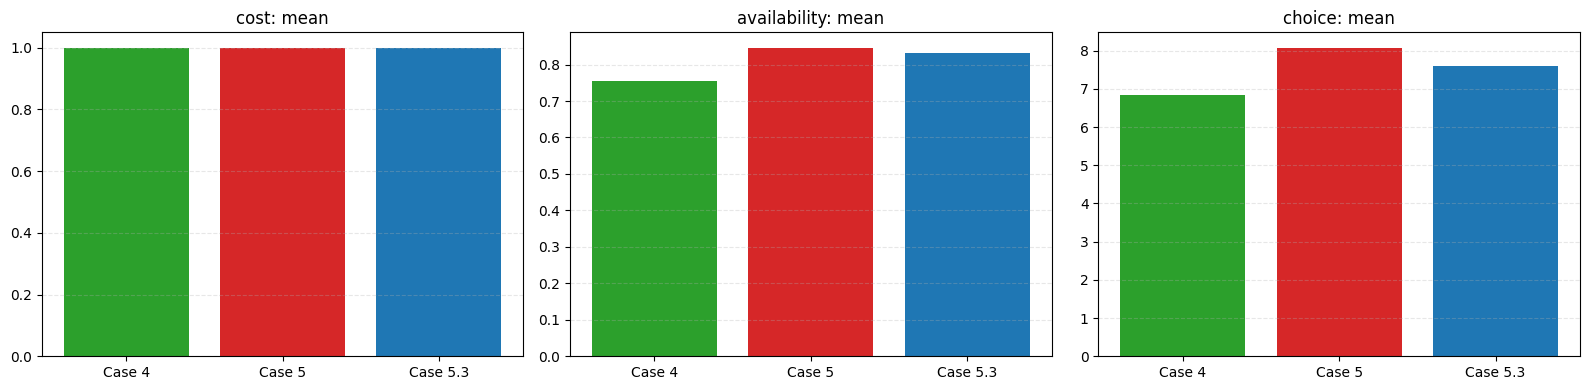

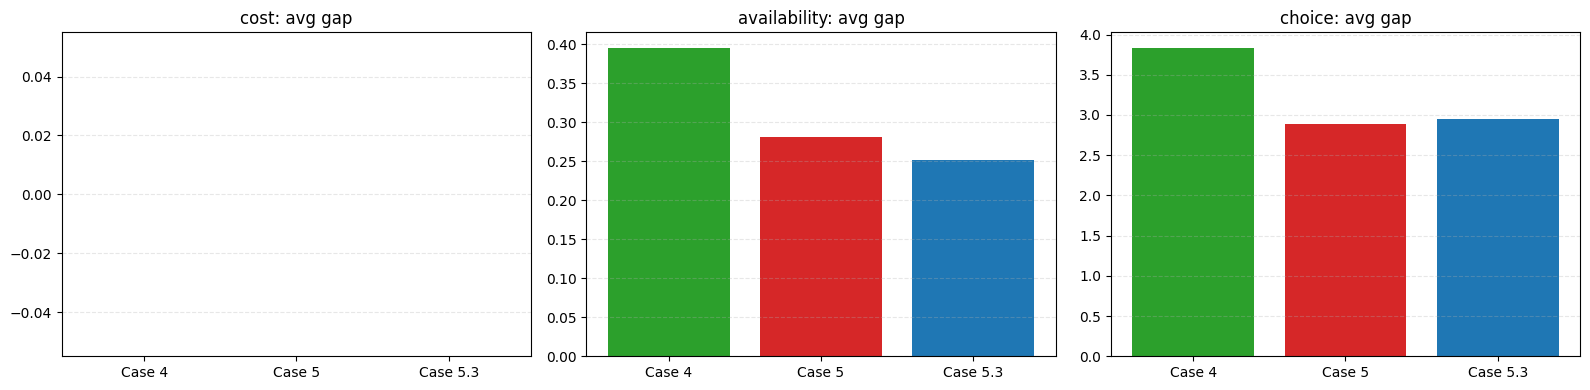

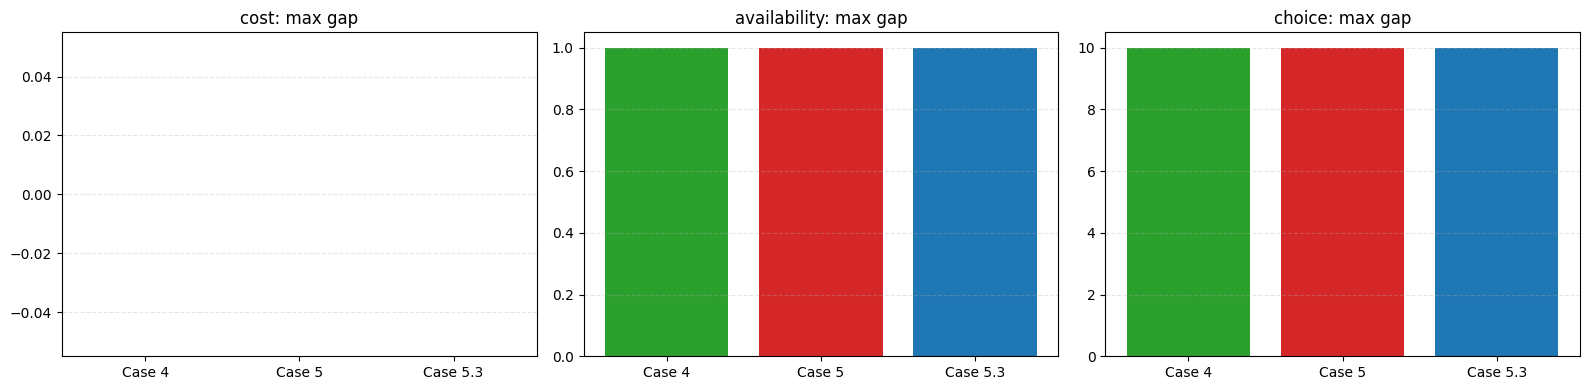

In [38]:
plot_cases = ["case4", "case5", "case53"]
plot_case_labels = [recourse_case_specs[c]["display"] for c in plot_cases]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, metric in zip(axes, ["cost", "availability", "choice"]):
    sub = recourse_summary_df[recourse_summary_df["metric"] == metric].set_index("case_alias").loc[plot_cases]
    ax.bar(plot_case_labels, sub["mean"].to_numpy(), color=["#2ca02c", "#d62728", "#1f77b4"])
    ax.set_title(f"{metric}: mean")
    ax.grid(axis="y", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, metric in zip(axes, ["cost", "availability", "choice"]):
    sub = recourse_summary_df[recourse_summary_df["metric"] == metric].set_index("case_alias").loc[plot_cases]
    ax.bar(plot_case_labels, sub["avg_gap"].to_numpy(), color=["#2ca02c", "#d62728", "#1f77b4"])
    ax.set_title(f"{metric}: avg gap")
    ax.grid(axis="y", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, metric in zip(axes, ["cost", "availability", "choice"]):
    sub = recourse_summary_df[recourse_summary_df["metric"] == metric].set_index("case_alias").loc[plot_cases]
    ax.bar(plot_case_labels, sub["max_gap"].to_numpy(), color=["#2ca02c", "#d62728", "#1f77b4"])
    ax.set_title(f"{metric}: max gap")
    ax.grid(axis="y", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()


In [39]:
for metric in ["cost", "availability", "choice"]:
    print(f"\nTop recourse explanation rules | metric={metric}")
    for alias in ["case4", "case5", "case53"]:
        p = recourse_table_paths[alias][metric]
        t = pd.read_csv(p, sep=';').sort_values('targetcol', ascending=False).head(10)
        print(f"{recourse_case_specs[alias]['display']}")
        display(t)



Top recourse explanation rules | metric=cost


KeyError: 'targetcol'

In [ ]:
print("Recourse case artifacts")
print("cfs:", recourse_cfs_paths)
print("tables:", recourse_table_paths)
print("summary csv:", recourse_summary_csv)
print("comparison csv:", recourse_compare_csv)
